## **Correcting Trend-Residual Covariance in Geostatistical Modeling Using Gram–Schmidt Orthogonalization**

#### Alexander Ifenaike

Email: aoi276@eid.utexas.edu | [GitHub](https://github.com/aifenaike) | [Linkedin](https://www.linkedin.com/in/alexander-ifenaike/) 

### **Executive Summary**

Subsurface spatial data often exhibits non-stationary behavior due to large-scale geological trends. Practitioners routinely separate these trends from local stochastic variability to simplify geostatistical modeling. However, this separation is only valid when the trend and residual are uncorrelated and their variances are additive — a condition that is rarely verified in practice.

Here, we use a 2D subsurface dataset to demonstrate that trend-residual covariance persists regardless of the trend modeling approach used. We then apply a Gram–Schmidt orthogonalization procedure to correct this coupling at sample locations and extend the correction across the full domain via simple kriging with a long-range variogram model. We evaluate the impact of the correction on the residual variogram, kriging local variance, simulation ensemble spread, and uncertainty calibration.

We find that neglecting trend-residual covariance significantly deflates the residual variogram sill, causing simulation ensembles to underestimate true subsurface variability and produce overconfident uncertainty intervals. We recommend applying this correction procedure as a standard quality control step in any geospatial workflow where trend modeling is employed prior to spatial simulation.


### **Table of Content**

1. Import Relevant Packages
2. Load & Visualize Data
3. Declare Helper Functions
4. Trend Modeling
    - Convolution Trend Model
    - ML Trend Model (Guassian Process Regression)
5. Covariance Correction with Gram-Schmidt Orthogonalization
6. Residual Variogram Modeling
7. Effect on residual Kriging
8. Effect on realizations from Sequential Guassian Simulation




### 1. Import Relevant Packages

First, we will install and import the Python packages required for this demonstration.

In [ ]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn scipy geostatspy astropy tqdm

In [32]:
from tqdm import tqdm                                         # suppress the status bar
from functools import partialmethod
tqdm.__init__ = partialmethod(tqdm.__init__, disable=True)

ignore_warnings = True                                        # ignore warnings
import numpy as np                                            # ndarrays for gridded data
import pandas as pd                                           # DataFrames for tabular data
import matplotlib.pyplot as plt                               # for plotting
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control of axes ticks
from matplotlib.colors import Normalize, TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

import math                                                   # trig etc.
import scipy.signal as signal                                 # kernel for moving window calculation
import astropy.convolution.convolve as convolve               # sparse data convolution
plt.rc('axes', axisbelow=True)                                # plot all grids below the plot elements

if ignore_warnings == True:                                   
    import warnings
    warnings.filterwarnings('ignore')
    
cmap = plt.cm.inferno                                         # color map

import geostatspy.GSLIB as GSLIB                              # GSLIB utilities, visualization and wrapper
import geostatspy.geostats as geostats                        # GSLIB methods convert to Python      
import geostatspy  

import itertools
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import WhiteKernel, Matern
from sklearn.preprocessing import StandardScaler

### 2. Load and Visualize the data

For this demonstration, we will use a sample 2D subsurface dataset from Michael Pyrcz’s open-source [GeoDataSets](https://github.com/GeostatsGuy/GeoDataSets) repository.

Next, we define the spatial grid parameters used throughout the analysis. These parameters establish the simulation domain, grid resolution, cell geometry, and coordinate system for our spatial dataset.

In [33]:
# --- Grid Parameters ---
xmin = 0.0; xmax = 1000.0                                     # range of x values
ymin = 0.0; ymax = 1000.0                                     # range of y values
dx = 10                                                       # grid spacing in meters
xsiz = 10; ysiz = 10                                          # cell size
nx = 100; ny = 100                                            # number of cells
xmn = 5; ymn = 5                                              # grid origin, location center of lower left cell

pormin = 0.05; pormax = 0.22                                  # set feature min and max for colorbars

x_cordinates = np.arange(0.0, xmax, xsiz)
y_cordinates = np.arange(0.0, ymax, ysiz)

In [34]:
def add_grid():
    plt.gca().grid(True, which='major',linewidth = 1.0); plt.gca().grid(True, which='minor',linewidth = 0.2) # add y grids
    plt.gca().tick_params(which='major',length=7); plt.gca().tick_params(which='minor', length=4)
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator()); plt.gca().yaxis.set_minor_locator(AutoMinorLocator()) # turn on minor ticks   



In [35]:
# Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/sample_data_MV_biased.csv") 
df = df[['X','Y','Porosity']]                                   # remove the unneeded features, columns
df.head(n=3)                                                    # preview the DataFrame

,X,Y,Porosity
0,100.0,900.0,0.101319
1,100.0,800.0,0.147676
2,100.0,700.0,0.145912


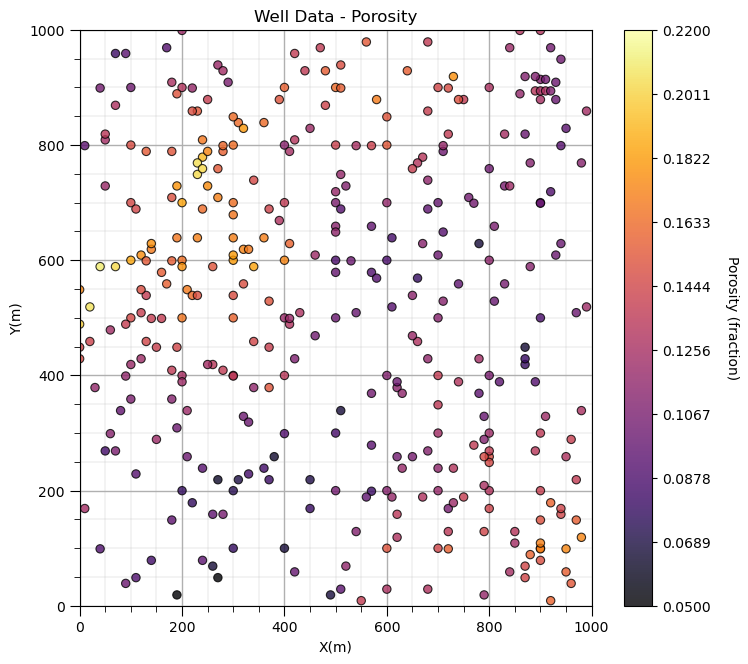

In [36]:
# Visualize spatial data
plt.subplot(111)
GSLIB.locmap_st(df,'X','Y','Porosity',xmin,xmax,ymin,ymax,pormin,pormax,'Well Data - Porosity','X(m)','Y(m)','Porosity (fraction)',cmap)
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.2, wspace=0.2, hspace=0.2); add_grid(); plt.show()


Training wells : 295
Holdout wells  : 73


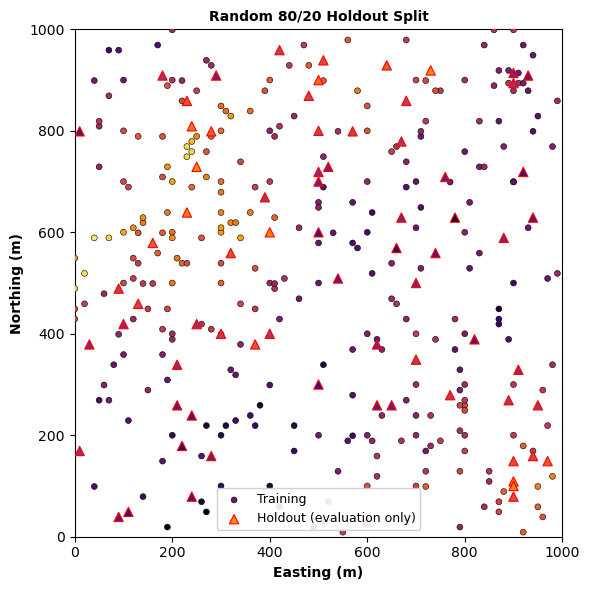

In [37]:

rng = np.random.default_rng(42)
holdout_idx = rng.choice(len(df), size=int(0.20 * len(df)), replace=False)
train_idx   = np.setdiff1d(np.arange(len(df)), holdout_idx)

df_train   = df.iloc[train_idx].reset_index(drop=True)   # 295 wells — fitting
df_holdout = df.iloc[holdout_idx].reset_index(drop=True) # 73 wells  — evaluation only

print(f"Training wells : {len(df_train)}")
print(f"Holdout wells  : {len(df_holdout)}")

# Visualise the split
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df_train["X"],   df_train["Y"],   c=df_train["Porosity"],
           cmap=cmap, vmin=pormin, vmax=pormax,
           s=18, edgecolors="k", linewidths=0.4, label="Training", zorder=3)
ax.scatter(df_holdout["X"], df_holdout["Y"], c=df_holdout["Porosity"],
           cmap=cmap, vmin=pormin, vmax=pormax,
           s=45, marker="^", edgecolors="red", linewidths=0.8,
           label="Holdout (evaluation only)", zorder=4)
ax.set_xlim(0, 1000); ax.set_ylim(0, 1000)
ax.set_xlabel("Easting (m)", fontsize=10, fontweight="bold")
ax.set_ylabel("Northing (m)", fontsize=10, fontweight="bold")
ax.set_title("Random 80/20 Holdout Split", fontsize=10, fontweight="bold")
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout(); plt.show()

In [38]:
por_grid = GSLIB.DataFrame2ndarray(df_train,'X','Y','Porosity',xmin, xmax, ymin, ymax, xsiz)

### 3. Declare Helper Functions

Before running the workflow, we define all helper functions used throughout this notebook. Each function handles a specific step in the covariance correction and visualization pipeline:

- **`gram_schmidt_orthogonalization`** — enforces zero covariance between trend and residual at sample locations via Gram-Schmidt projection in Hilbert space
- **`visualize_trend_and_variance_decomposition`** — maps the fitted trend surface and displays the variance decomposition pie chart after trend modeling
- **`plot_variance_decomposition`** — compares variance decomposition before and after GS correction side by side
- **`plot_reconstructed_fields`** — four-panel comparison showing the trend before correction, the kriged adjustment surface, and the corrected trend



In [39]:
# =============================================================================
# Helper Functions for Gram-Schmidt Orthogonalization
# =============================================================================

def var(x):
    # Sample variance (ddof=1) — unbiased estimator of population variance
    return np.var(x, ddof=1)

def demean(A):
    """
    Remove the spatial mean from array A.
    Demeaning is required before orthogonalization — Gram-Schmidt operates 
    in a zero-mean Hilbert space where inner products measure covariance.
    """
    return A - float(np.mean(A))

def rescale_to_var(A, v_target, eps=1e-12):
    """
    Center A and rescale it to a target sample variance.
    Used to restore the variance magnitude of a component after orthogonalization
    if the original variance needs to be preserved for downstream modeling.
    """
    A0 = A - A.mean()
    v  = float(A0.var())
    if v < eps:
        return A0   # degenerate case: array is constant, nothing to rescale
    return A0 * np.sqrt(max(v_target, 0.0) / v)

def norm2(v, eps=1e-12):
    """
    Euclidean norm with a small floor (eps) to prevent division by zero.
    Used internally when normalizing vectors during projection.
    """
    return float(np.sqrt(np.dot(v, v))) + eps

def gram_schmidt_orthogonalization(A, B, eps=1e-12):
    """
    Remove the component of trend B that is aligned with residual A,
    enforcing zero covariance between trend and residual at sample locations.

    Gram-Schmidt projection in Hilbert space:
        Given demeaned vectors a (residual) and b (trend):
            b_perp = b - alpha * a
        where:
            alpha = <b, a> / <a, a>   (projection coefficient)

        This guarantees <a, b_perp> = 0 — the corrected trend is orthogonal 
        to the residual, eliminating the hidden covariance term.

    The projection coefficient alpha quantifies the severity of coupling:
        alpha ≈ 0  → negligible coupling, correction has minimal effect
        alpha >> 0 → significant coupling, correction is necessary

    Parameters
    ----------
    A   : ndarray — residual vector (reference direction)
    B   : ndarray — trend vector to be orthogonalized
    eps : float   — numerical floor to prevent division by zero

    Returns
    -------
    A_orth : demeaned residual (unchanged — used as reference)
    B_orth : corrected trend with mean restored, orthogonal to A
    """
    if A.shape != B.shape:
        raise ValueError(f"A and B must have the same shape, got {A.shape} vs {B.shape}")

    if A.ndim not in (1, 2):
        raise ValueError(f"Expected 1D or 2D arrays; got ndim={A.ndim}")

    # Step 1: Demean both vectors — orthogonalization is performed in zero-mean space
    A0 = demean(A)
    B0 = demean(B)

    # Step 2: Flatten to 1D for inner product computation
    a = A0.ravel()
    b = B0.ravel()

    aa = float(np.dot(a, a))   # <a, a> — squared norm of residual vector

    if aa < eps:
        # Degenerate case: residual has near-zero variance — projection undefined
        # Return demeaned inputs unchanged; correction cannot be applied
        A_orth = A0.copy()
        B_orth = B0.copy()
        alpha  = 0.0
        print("Warning: degenerate residual — orthogonalization skipped")
    else:
        # Step 3: Compute projection coefficient alpha = <b, a> / <a, a>
        # alpha represents the fraction of trend variance aligned with the residual
        alpha  = float(np.dot(b, a)) / (aa + eps)
        print(f"Projection Coefficient (alpha): {alpha:.6f}")

        # Step 4: Remove the coupled component from the trend
        # b_perp = b - alpha * a  →  <a, b_perp> = 0
        b_perp = b - alpha * a

        A_orth = A0.copy()
        B_orth = b_perp.reshape(B.shape)

    # Step 5: Restore the original trend mean — correction operates on the 
    # zero-mean component only, preserving the large-scale trend level
    B_orth = B_orth + B.mean()

    return A_orth, B_orth

In [40]:
def smooth_krige_GS_adjustments(sampled_df, model_name, dx, nx, ny):
    """Propagate Gram-Schmidt correction from well locations to the full grid using kriging."""

    if model_name.lower() not in ["convolution", "gp"]:
        raise ValueError("model_name must be either 'Convolution' or 'GP'")
    
    # Range of adjustment values at well locations — used to bound kriging estimates
    diff_min = sampled_df[f'{model_name}_GS_adjustments'].min()
    diff_max = sampled_df[f'{model_name}_GS_adjustments'].max()

    # Long-range variogram parameters — captures the smooth, large-scale 
    # spatial structure of the correction field
    diff_vrange_maj = 800   # major range (m): long range to ensure smooth propagation
    diff_vrange_min = 800   # minor range (m): isotropic correction assumed
    diff_vazi       = 0.0   # variogram azimuth (degrees): no preferred direction
    diff_vrel_nugget = 0.2  # nugget effect: small nugget reflects spatial continuity of the correction field

    # Kriging mean and sill estimated from the sample adjustments
    diff_skmean = np.average(sampled_df[f'{model_name}_GS_adjustments'].values)  # global mean of corrections
    diff_sill   = np.var(sampled_df[f'{model_name}_GS_adjustments'].values)      # variance of corrections at wells

    # Build variogram model for the adjustment field
    # Exponential model with long range ensures smooth spatial interpolation
    por_vario = GSLIB.make_variogram(
        nug=diff_vrel_nugget, nst=1, it1=2,
        cc1=1.0 - diff_vrel_nugget,
        azi1=diff_vazi,
        hmaj1=diff_vrange_maj,
        hmin1=diff_vrange_min
    )

    # Kriging search and estimation parameters
    ktype  = 1   # kriging type: 1 = ordinary kriging (estimates local mean from neighbors)
    radius = 800 # search radius (m): includes all wells within range of each grid node
    nxdis  = 1   # grid discretizations for block kriging (1 = point kriging)
    nydis  = 1
    ndmin  = 5   # minimum number of neighboring wells required for an estimate
    ndmax  = 20  # maximum number of neighboring wells used per estimate

    # Cell-centered grid origin — ensures estimates align with simulation grid
    xmn = dx / 2.0
    ymn = dx / 2.0
    xsiz = dx
    ysiz = dx

    # Run 2D kriging to propagate the GS adjustment to all grid nodes
    # diff_kmap: kriged adjustment surface | diff_vmap: kriging variance surface
    diff_kmap, diff_vmap = geostats.kb2d(
        sampled_df, 'X', 'Y',
        f'{model_name}_GS_adjustments',
        diff_min, diff_max,
        nx, xmn, xsiz,
        ny, ymn, ysiz,
        nxdis, nydis,
        ndmin, ndmax,
        radius, ktype,
        diff_skmean, por_vario
    )

    return diff_kmap  

In [41]:
# =============================================================================
# Helper Functions for Visualization of Results
# =============================================================================

def visualize_trend_and_variance_decomposition(df, model_name, porosity_trend, cmap):
    """
    Visualize the fitted trend surface and variance decomposition after trend modeling.

    Two panels are shown side by side:
      - Left  : Spatial map of the fitted trend overlaid with well observations
      - Right : Variance decomposition chart showing how total porosity variance 
                is partitioned into trend, residual, and covariance components

    A pie chart is used when covariance is positive, a horizontal bar chart is used when covariance is negative.

    Parameters
    ----------
    df             : DataFrame with columns {model_name}_Trend and {model_name}_Residual
    model_name     : "Convolution" or "GP"
    porosity_trend : 2D trend grid (GSLIB convention, row 0 = top)
    cmap           : colormap for the spatial trend map
    """
    if model_name.lower() not in ["convolution", "gp"]:
        raise ValueError("model_name must be either 'Convolution' or 'GP'")

    # ── Variance Decomposition ───────────────────────────────────────────────
    # Decompose total porosity variance into three components:
    #   σ²_z = σ²_m + σ²_R + 2Cov(m, R)
    # A non-zero covariance term indicates trend-residual coupling
    var_trend = np.var(df[f"{model_name}_Trend"])
    var_resid = np.var(df[f"{model_name}_Residual"])
    cov_tr    = np.cov(df[f"{model_name}_Trend"], df[f"{model_name}_Residual"])[0, 1]

    var_total = var_trend + var_resid + 2 * cov_tr

    # Express each component as a proportion of total variance
    percent_trend      = var_trend    / var_total
    percent_residual   = var_resid    / var_total
    percent_covariance = 2 * cov_tr   / var_total   # this should be ~0 for a clean decomposition

    fig = plt.figure(figsize=(11, 5))

    # ── Left Panel: Trend Surface Map ────────────────────────────────────────
    # Shows the fitted trend surface across the reservoir with well locations overlaid
    ax1 = fig.add_axes([0.07, 0.12, 0.55, 0.78])
    plt.sca(ax1)
    GSLIB.locpix_st(
        porosity_trend,
        xmin, xmax, ymin, ymax, xsiz,
        pormin, pormax,
        df, "X", "Y", "Porosity",
        f"Porosity Data and {model_name} Based Trend",
        "X(m)", "Y(m)",
        "Porosity (fraction)",
        cmap
    )

    # ── Right Panel: Variance Decomposition Chart ────────────────────────────
    # Pie chart when covariance >= 0: the exploded covariance slice visually 
    # Bar chart when covariance < 0: pie charts cannot handle negative values,

    ax2 = fig.add_axes([0.70, 0.22, 0.25, 0.55])

    values = [percent_trend, percent_residual, percent_covariance]
    labels = ["Trend", "Residual", "Covariance"]
    colors = ["#ff9999", "#66b3ff", "#edf23a"]

    if percent_covariance >= 0:
        # Explode all slices slightly; the covariance slice stands out as the problem term
        ax2.pie(
            values,
            labels=labels,
            autopct="%1.1f%%",
            startangle=90,
            colors=colors,
            explode=[0.03, 0.03, 0.03],
            wedgeprops={"edgecolor": "black", "linewidth": 1},
            textprops={"fontsize": 10},
        )
    else:
        # Negative covariance: use horizontal bars with a zero reference line
        bars = ax2.barh(labels, values, color=colors, edgecolor="black", linewidth=1)
        ax2.axvline(0, color="black", linewidth=0.8)
        ax2.set_xlim(-0.5, 1.0)
        ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
        # Annotate each bar with its percentage value
        for bar, val in zip(bars, values):
            x = bar.get_width()
            ax2.text(
                x + (0.02 if x >= 0 else -0.02),
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1%}", va="center",
                ha="left" if x >= 0 else "right", fontsize=9
            )

    ax2.set_title("Variance Decomposition\nPost-Trend Modeling", fontsize=11)

    plt.show()

In [42]:
def plot_reconstructed_fields(df, model_name, trend_grid, diff_kmap, gs_trend_grid, figsize=(20, 5)):
    """
    Four-panel comparison showing the effect of GS orthogonalization on the trend surface.

    Reading left to right, the panels tell the correction story:
      Col 0 — Porosity observations (reference)
      Col 1 — Fitted trend before correction (may absorb residual variance)
      Col 2 — Kriged GS adjustment surface (the correction field propagated to the grid)
      Col 3 — Corrected trend after GS orthogonalization (variance reallocated to residual)

    Parameters
    ----------
    df            : DataFrame with columns Porosity, {model_name}_Trend,
                    {model_name}_GS_adjustments, {model_name}_GS_Trend
    model_name    : "Convolution" or "GP"
    trend_grid    : trend grid before GS correction   (GSLIB convention, row 0 = top)
    diff_kmap     : kriged GS adjustment grid          (GSLIB convention, row 0 = top)
    gs_trend_grid : GS-corrected trend grid            (GSLIB convention, row 0 = top)
    """
    if model_name.lower() not in ["convolution", "gp"]:
        raise ValueError("model_name must be 'Convolution' or 'GP'")

    # Flip grids for imshow origin="lower" (GSLIB row 0 = top → needs vertical flip)
    truth    = np.flipud(por_grid)
    trend    = np.flipud(trend_grid)
    kd       = np.flipud(diff_kmap)
    trend_gs = np.flipud(gs_trend_grid)

    # Colorscale for observations: anchored to observed porosity range at wells
    norm_truth = Normalize(vmin=df["Porosity"].min(), vmax=df["Porosity"].max())

    # Shared colorscale for pre- and post-GS trends — enables direct visual comparison
    norm_trend = Normalize(vmin=min(trend.min(), trend_gs.min()),
                           vmax=max(trend.max(), trend_gs.max()))

    # Diverging colorscale for adjustment surface — centered at zero
    # Red = positive adjustment (trend increased), Blue = negative (trend decreased)
    kd_lim  = max(abs(kd.min()), abs(kd.max()))
    norm_kd = TwoSlopeNorm(vmin=-kd_lim, vcenter=0.0, vmax=kd_lim)

    extent = [xmin, xmax, ymin, ymax]
    fig, axes = plt.subplots(1, 4, figsize=figsize)

    def _imshow(ax, data, cmap_, norm):
        # Render grid as image with geographic extent
        return ax.imshow(data, origin="lower", extent=extent,
                         cmap=cmap_, norm=norm, aspect="equal")

    def _scatter(ax, c, cmap_, norm):
        # Overlay well locations colored by their respective attribute value
        ax.scatter(df["X"], df["Y"], c=c, cmap=cmap_, norm=norm,
                   s=15, edgecolors="k", linewidths=0.5, zorder=5)

    def _fmt(ax, title, ylabel=False):
        ax.set_title(title, fontsize=10, pad=4)
        ax.set_xlabel("Easting (m)", fontsize=9)
        if ylabel:
            ax.set_ylabel("Northing (m)", fontsize=9)
        ax.tick_params(labelsize=8)

    def _cbar(ax, im, label):
        # Attach a colorbar to the right of each panel
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.06)
        cb  = fig.colorbar(im, cax=cax)
        cb.set_label(label, fontsize=9)
        cb.ax.tick_params(labelsize=8)

    # ── Col 0: Ground Truth ──────────────────────────────────────────────────
    # Reference panel — observed porosity at well locations interpolated to grid
    im0 = _imshow(axes[0], truth, cmap, norm_truth)
    _scatter(axes[0], df["Porosity"], cmap, norm_truth)
    _fmt(axes[0], "Porosity (Ground Truth)", ylabel=True)
    _cbar(axes[0], im0, "Porosity (frac.)")

    # ── Col 1: Trend Before Correction ──────────────────────────────────────
    im1 = _imshow(axes[1], trend, cmap, norm_trend)
    _scatter(axes[1], df[f"{model_name}_Trend"], cmap, norm_trend)
    _fmt(axes[1], f"{model_name} Trend (No-GS)")
    _cbar(axes[1], im1, "Porosity (frac.)")

    # ── Col 2: Kriged GS Adjustment Surface ─────────────────────────────────
    im2 = _imshow(axes[2], kd, "RdBu_r", norm_kd)
    _scatter(axes[2], df[f"{model_name}_GS_adjustments"], "RdBu_r", norm_kd)
    _fmt(axes[2], "Kriged GS Adjustments")
    _cbar(axes[2], im2, "Adjustment")

    # ── Col 3: Corrected Trend After GS Orthogonalization ───────────────────
    im3 = _imshow(axes[3], trend_gs, cmap, norm_trend)
    _scatter(axes[3], df[f"{model_name}_GS_Trend"], cmap, norm_trend)
    _fmt(axes[3], f"{model_name} Trend (Post-GS)")
    _cbar(axes[3], im3, "Porosity (frac.)")

    plt.tight_layout()
    plt.show()

In [43]:
def plot_variance_decomposition(df, model_name, colors=None):
    """
    Displays two side-by-side charts showing how total porosity variance is 
    partitioned into trend, residual, and covariance components before and 
    after the Gram-Schmidt correction.
    
    Parameters
    ----------
    df         : DataFrame containing porosity, trend, and residual columns
    model_name : "Convolution" or "GP"
    colors     : list of 3 colors [Trend, Residual, Covariance]
    """
    if model_name.lower() not in ["convolution", "gp"]:
        raise ValueError("model_name must be 'Convolution' or 'GP'")

    if colors is None:
        colors = ['#CC5801', '#66b3ff', '#FFFF66']

    # Total porosity variance at well locations — the budget that must be conserved
    Z_samples = np.asarray(df["Porosity"])
    var_z     = float(np.var(Z_samples, ddof=1))

    # Define pre- and post-GS component pairs for each panel
    datasets = [
        (df[f"{model_name}_Trend"],    df[f"{model_name}_Residual"],    f"{model_name} Trend (No-GS)"),
        (df[f"{model_name}_GS_Trend"], df[f"{model_name}_GS_Residual"], f"{model_name} Trend (Post-GS)"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(8, 5))

    for ax, (trend, residual, title) in zip(axes, datasets):
        trend    = np.asarray(trend)
        residual = np.asarray(residual)

        # Compute variance components at well locations
        var_t  = float(np.var(trend,    ddof=1))
        var_r  = float(np.var(residual, ddof=1))
        cov_tr = var_z - var_t - var_r   # residual of variance budget = 2*Cov(T,R)

        # Express each component as a percentage of total porosity variance
        pct_t   = var_t  / var_z * 100
        pct_r   = var_r  / var_z * 100
        pct_cov = cov_tr / var_z * 100   # signed: positive = deflated sill, negative = inflated sill


        ax.set_title(f"{title}\n%Cov(T,R) = {pct_cov:.1f}%",
                     fontsize=10, fontweight='bold')

        if pct_cov >= 0:
            # ── Pie Chart (Positive Coupling) ────────────────────────────────
            sizes      = [pct_t, pct_r]
            labels     = ['Trend', 'Residual']
            pie_colors = [colors[0], colors[1]]

            # Only add covariance slice if it is non-negligible (>= 0.05%)
            if abs(pct_cov) >= 0.05:
                sizes.append(pct_cov)
                labels.append('Covariance')
                pie_colors.append(colors[2])

            wedges, texts, autotexts = ax.pie(
                sizes,
                labels=labels,
                colors=pie_colors,
                autopct='%1.1f%%',
                startangle=90,
                wedgeprops=dict(edgecolor='white', linewidth=1.2)
            )
            for at in autotexts:
                at.set_fontsize(9)
            for t in texts:
                t.set_fontsize(9)

        else:
            # ── Signed Bar Chart (Negative Coupling) ─────────────────────────
            bar_labels  = ['Trend', 'Residual', 'Covariance', 'Total']
            bar_colors  = colors + ['#888888']
            bar_heights = [pct_t, pct_r, abs(pct_cov), 100.0]
            bar_bottoms = [0,     0,     pct_cov,       0    ]
            text_values = [pct_t, pct_r, pct_cov,       100.0]

            bars = ax.bar(
                bar_labels,
                bar_heights,
                bottom=bar_bottoms,
                color=bar_colors,
                edgecolor='white',
                linewidth=1.2,
                width=0.5
            )

            # Annotate each bar with its percentage value
            for bar, val, bottom in zip(bars, text_values, bar_bottoms):
                y_pos = bottom + bar.get_height() / 2
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    y_pos,
                    f'{val:.1f}%',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold', color='black'
                )

            # Reference lines: 100% = total variance budget, 0% = zero baseline
            ax.axhline(100, color='black', linewidth=1.0, linestyle='--', alpha=0.5)
            ax.axhline(0,   color='black', linewidth=0.8, linestyle='-',  alpha=0.3)
            ax.set_ylabel('% of Var(Z)', fontsize=9)
            ax.set_ylim(pct_cov - 10, 115)
            ax.tick_params(axis='both', labelsize=9)
            ax.spines[['top', 'right']].set_visible(False)

            # Annotation explaining the negative covariance interpretation
            ax.text(
                0.98, 0.97,
                'Negative 2·Cov(T,R):\nVar(T) + Var(R) > Var(Z)',
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=7.5, color='gray', style='italic'
            )

    fig.suptitle(
        f'{model_name} Trend — Variance Decomposition: Pre vs Post GS Orthogonalization',
        fontsize=11, fontweight='bold', y=1.02
    )
    fig.tight_layout()
    plt.show()

### 4. Trend Modeling

#### 4.1 Rigid Trend Model (Convolution)

We begin trend modeling with a Gaussian convolution filter as a rigid, minimum-baseline trend model. This applies a fixed spatial smoother to the porosity grid without any data-driven parameter learning. 

This represents the simplest possible trend extraction approach, where the degree of smoothing is controlled entirely by the kernel bandwidth (σ). 

Our objective here is to demonstrate the correction workflow on this first and establish that it works even for the most constrained trend modeling choice, before we introduce the more flexible models.

In [44]:
# =============================================================================
# Helper Function for Convolution Trend Kernel
# =============================================================================

def make_Gaussian_kernel(sigma,nc,csiz):  
    """
    Generate a normalized 2D Gaussian kernel.

    Parameters:
        sigma (float): Standard deviation of the Gaussian distribution.
        nc (int): Number of cells in both x and y directions.
        csiz (float): Cell size used to scale spatial coordinates.

    Returns: Normalized 2D Gaussian kernel whose values sum to 1.
    """               
    kernel = np.zeros((nc,nc))                                 
    for iy in range(0,nc):
        y = (iy - 100)*csiz
        for ix in range(0,nc):
            x = (ix - 100)*csiz
            kernel[iy,ix] = math.exp(-1*(y**2+x**2)/(2*sigma**2))/(2*math.pi*sigma**2)
    kernel = kernel/np.sum(kernel.flatten())                  
    return kernel

In [45]:
# Kernel parameters — sigma controls smoothing radius, nc controls kernel extent
sigma = 100   # smoothing radius (m): captures regional trend, avoids local variability
nc    = 201   # kernel grid size: large enough to avoid edge truncation of the Gaussian

kernel = make_Gaussian_kernel(sigma=sigma, nc=nc, csiz=xsiz)
kmax   = np.max(kernel.flatten())  

# Convolve the porosity grid with the Gaussian kernel to extract the trend surface
# boundary='extend' and nan_treatment='interpolate' handle grid edges and missing values
porosity_trend = convolve(
    por_grid, kernel,
    boundary='extend',
    nan_treatment='interpolate',
    normalize_kernel=True
)

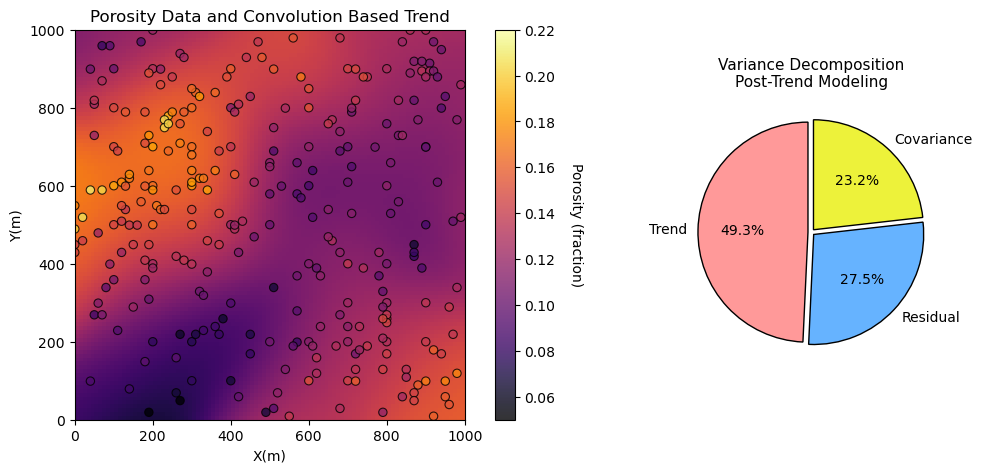

In [46]:
# Extract trend and residual at well locations
df_train = GSLIB.sample(porosity_trend, xmin, ymin, xsiz,"Convolution_Trend", df_train, "X", "Y")

df_train["Convolution_Residual"] = df_train["Porosity"] - df_train["Convolution_Trend"]

visualize_trend_and_variance_decomposition(df_train, "Convolution", porosity_trend, cmap)

#### 4.2. FLexible ML Trend Model (Guassian Process Regression)

The correction is designed to be model-agnostic. Having already fitted a Convolution trend model, we now demonstrate this by fitting a Gaussian Process Regression trend model as a second, more flexible alternative. 

Hyperparameters are selected purely by spatial block cross-validation to ensure the GPR captures large-scale geological structure without overfitting to local variability at well locations, then the model is refit on all wells to produce the final trend surface across the full simulation grid.

In [47]:
# =============================================================================
# Spatial Block Cross-Validation
# =============================================================================

def spatial_block_folds(X, n_blocks_side=3):
    """
    Divide the reservoir domain into a spatial grid of blocks.
    
    Each fold withholds one geographic block as validation, ensuring training 
    and validation wells are spatially separated. This prevents the model from 
    simply interpolating between nearby wells — it must generalize across space,
    which is the actual challenge in reservoir modeling.
    """
    x_edges = np.linspace(X[:, 0].min(), X[:, 0].max(), n_blocks_side + 1)
    y_edges = np.linspace(X[:, 1].min(), X[:, 1].max(), n_blocks_side + 1)

    # Assign each well to a spatial block based on its X, Y coordinates
    xi = np.digitize(X[:, 0], x_edges[1:-1])
    yi = np.digitize(X[:, 1], y_edges[1:-1])
    block_id = xi * n_blocks_side + yi

    # Build folds: each block takes a turn as the held-out validation set
    folds = []
    for b in range(n_blocks_side ** 2):
        val_idx   = np.where(block_id == b)[0]
        train_idx = np.where(block_id != b)[0]
        if len(val_idx) > 0 and len(train_idx) > 0:
            folds.append((train_idx, val_idx))

    print(f"  Spatial CV: {len(folds)} blocks, "
          f"avg {np.mean([len(v) for _, v in folds]):.0f} wells per validation block")
    return folds


# =============================================================================
# Kernel Builder — Matérn ν=1.5, Fixed Hyperparameters
# =============================================================================

def _build_kernel(length_scale, noise_level):
    """
    Build a Matérn ν=1.5 kernel with additive white noise.
    Matérn is well-suited for subsurface trend modeling since it produces smoother predictions than the RBF kernel.
    """
    return (
        Matern(length_scale=length_scale, length_scale_bounds="fixed", nu=1.5)
        + WhiteKernel(noise_level=noise_level, noise_level_bounds="fixed")
    )


# =============================================================================
# Cross-Validation MSE for a Single Hyperparameter Combination
# =============================================================================

def _cv_mse(X, y, folds, length_scale, noise_level):
    """
    Evaluate a (length_scale, noise_level) pair via spatial block CV.
    
    Returns the mean squared error averaged across all spatial folds.
    A large return value (1e6) is used as a penalty if the GP fails to fit, ensuring failed configurations are never selected as optimal.
    """
    fold_mse = []
    for train_idx, val_idx in folds:
        # Standardize targets within each fold to keep noise_level on a consistent scale
        scaler = StandardScaler()
        y_train = scaler.fit_transform(y[train_idx].reshape(-1, 1)).ravel()
        gp = GaussianProcessRegressor(
            kernel=_build_kernel(length_scale, noise_level),
            alpha=1e-6,
            optimizer=None,       # grid search owns hyperparameters — MLL optimizer disabled
            normalize_y=False,
            random_state=42,
        )
        try:
            gp.fit(X[train_idx], y_train)
            preds = scaler.inverse_transform(
                gp.predict(X[val_idx]).reshape(-1, 1)
            ).ravel()
            fold_mse.append(np.mean((y[val_idx] - preds) ** 2))
        except Exception:
            return 1e6   # penalize failed fits heavily
    return float(np.mean(fold_mse))


# =============================================================================
# GPR Trend Model with Spatial Block CV Hyperparameter Selection
# =============================================================================

def tune_gp_trend_model(
    features, targets, grid_coords, ny, nx,
    n_blocks_side=3,
    ls_min=300, ls_max=900, ls_steps=10,
    noise_steps=10, verbose=False,
):
    """
    Fit a GPR spatial trend model with hyperparameters selected by spatial block CV.

    Key design decisions for geostatistical admissibility:
      - Length-scale is bounded below (ls_min) to prevent the GP from fitting 
        short-range structure that belongs to the residual component
      - Hyperparameters are fixed after grid search 
      - Final model is refit on all wells using the best hyperparameters to 
        produce the trend surface across the full simulation grid

    Parameters
    ----------
    ls_min, ls_max : float
        Length-scale search bounds (metres). ls_min should exceed the range 
        where local variability begins — prevents the trend from absorbing 
        stochastic structure that belongs to the residual.
    ls_steps : int
        Number of length-scale candidates in the grid search (linear spacing).
    noise_steps : int
        Number of noise-level candidates (log spacing, 1e-3 to 1.0 in 
        standardised units where Var(y_scaled) ≈ 1).
    """
    X = features.values if hasattr(features, 'values') else np.array(features)
    y = targets.values  if hasattr(targets,  'values') else np.array(targets)

    folds = spatial_block_folds(X, n_blocks_side=n_blocks_side)

    # Define hyperparameter search grids
    ls_grid    = np.linspace(ls_min, ls_max, ls_steps)
    noise_grid = np.logspace(-3, 0, noise_steps)

    best_mse   = np.inf
    best_ls    = ls_grid[ls_steps // 2]
    best_noise = noise_grid[noise_steps // 2]

    if verbose:
        print(f"  Grid search: {ls_steps} x {noise_steps} = {ls_steps * noise_steps} combinations")

    # Evaluate every (length_scale, noise_level) combination via spatial CV
    for ls, noise in itertools.product(ls_grid, noise_grid):
        mse = _cv_mse(X, y, folds, ls, noise)
        if mse < best_mse:
            best_mse, best_ls, best_noise = mse, ls, noise

    if verbose:
        print(f"  Best length_scale : {best_ls:.1f} m")
        print(f"  Best noise_level  : {best_noise:.4f}")
        print(f"  CV-MSE            : {best_mse:.6f}")

    # Refit on all wells using best hyperparameters — produces the final trend surface
    final_scaler = StandardScaler()
    y_scaled = final_scaler.fit_transform(y.reshape(-1, 1)).ravel()

    best_gp = GaussianProcessRegressor(
        kernel=_build_kernel(best_ls, best_noise),
        alpha=1e-6,
        optimizer=None,
        normalize_y=False,
        random_state=42,
    )
    best_gp.fit(X, y_scaled)

    # Predict trend across the full simulation grid and reshape to 2D
    trend_grid = final_scaler.inverse_transform(
        best_gp.predict(grid_coords).reshape(-1, 1)
    ).ravel().reshape(ny, nx)

    return {
        "model"             : best_gp,
        "trend_grid"        : trend_grid,       # full-domain trend surface
        "scaler"            : final_scaler,
        "best_length_scale" : best_ls,          # optimal spatial range (m)
        "best_noise_level"  : best_noise,       # optimal noise variance
        "cv_mse"            : best_mse,         # spatial CV error of best model
    }

  Spatial CV: 9 blocks, avg 33 wells per validation block
  Grid search: 10 x 10 = 100 combinations
  Best length_scale : 300.0 m
  Best noise_level  : 0.4642
  CV-MSE            : 0.000473


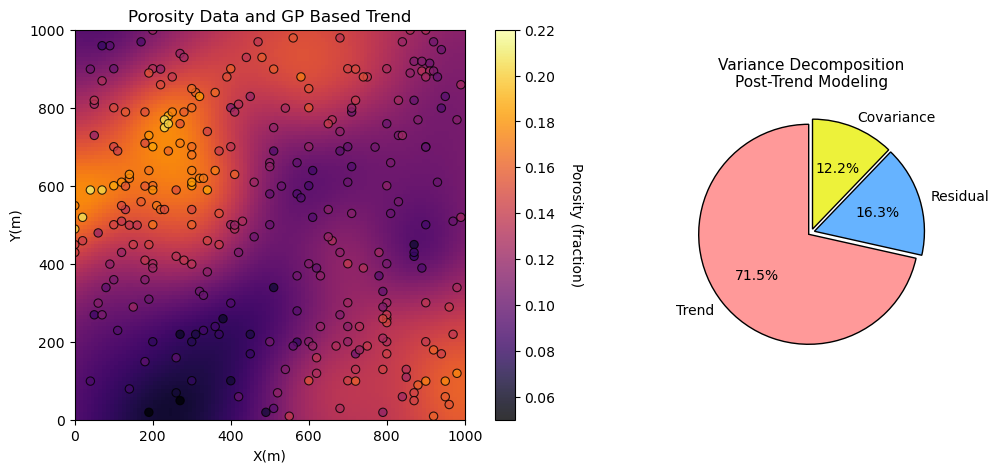

In [48]:
# Build full-resolution grid coordinates for trend prediction
# ys runs high-to-low so that row 0 corresponds to the top of the map (GSLIB convention)
xs = np.linspace(dx / 2, xmax - dx / 2, nx)
ys = np.linspace(ymax - dx / 2, dx / 2, ny)
gx, gy = np.meshgrid(xs, ys)
grid_coords = np.column_stack([gx.ravel(), gy.ravel()])  # (nx*ny, 2) array of (X, Y) pairs

# Fit GPR trend model — hyperparameters selected by spatial block CV
GP_result = tune_gp_trend_model(df_train[["X", "Y"]], df_train["Porosity"], grid_coords, ny, nx, verbose=True)

# Sample the fitted trend surface back at well locations
# This gives the trend estimate at each well, needed to compute the residual
df_train = GSLIB.sample(GP_result["trend_grid"], xmin, ymin, xsiz, "GP_Trend", df_train, "X", "Y")

# Residual = observed porosity minus the fitted trend at each well
# This is the stochastic component that will be used in variogram modeling and simulation
df_train["GP_Residual"] = df_train["Porosity"] - df_train["GP_Trend"]

# Visualize the trend surface and variance decomposition (Cov%, trend share, residual share)
visualize_trend_and_variance_decomposition(df_train, "GP", GP_result["trend_grid"], cmap)

### 5. Covariance Correction with Gram-Schmidt Orthogonalization

With the trend models fitted, we now apply Gram–Schmidt orthogonalization to enforce zero covariance between trend and residual at well locations, then propagate the correction to the full grid via kriging. 

This two-step process (correct at wells, krige to grid) is applied to each trend model independently. We begin with the Convolution trend model.

In [49]:
#  ── Step 1: Gram-Schmidt (GS) Orthogonalization at Well Locations ──────────────
# Decomposes the Convolution trend into two components:
#   - A component aligned with the residual (coupled variance) → reassigned to residual
#   - An orthogonal component (corrected trend) → zero covariance with residual
_, well_point_trend_gs = gram_schmidt_orthogonalization(df_train["Convolution_Residual"], df_train["Convolution_Trend"])

# Recompute residuals using the corrected trend
updated_residuals = df_train['Porosity'].to_numpy() - well_point_trend_gs

# Store corrected trend, residuals, and the point-wise adjustment at well locations
df_train['Convolution_GS_Trend'] = well_point_trend_gs   # orthogonalized trend at wells
df_train['Convolution_GS_Residual'] = updated_residuals  # updated residuals after correction
diff = well_point_trend_gs - df_train["Convolution_Trend"]
df_train['Convolution_GS_adjustments'] = diff       # correction magnitude at each well location


# ── Step 2: Propagate GS Correction from Wells to Full Grid via Kriging ────────
Convolution_diff_kmap = smooth_krige_GS_adjustments(df_train,"Convolution",dx=dx,nx=nx,ny=ny)                    # GSLIB convention

# Add the kriged correction to the original GPR trend surface
Convolution_GS_Trend_grid = porosity_trend + Convolution_diff_kmap


Projection Coefficient (alpha): 0.420161
  Estimated   10000 blocks 
      average   0.0006695099162229133  variance  1.71474230808979e-05


We repeat the same Gram–Schmidt correction and kriging propagation workflow for the GP trend model.

In [50]:
# ── Step 1: Gram-Schmidt (GS) Orthogonalization at Well Locations ──────────────
# Decomposes the GPR trend 
_, well_point_trend_gs = gram_schmidt_orthogonalization(df_train["GP_Residual"], df_train["GP_Trend"])

# Recompute residuals using the corrected trend
updated_residuals = df_train['Porosity'].to_numpy() - well_point_trend_gs

# Store corrected trend, residuals, and the point-wise adjustment at well locations
df_train['GP_GS_Trend']       = well_point_trend_gs   # orthogonalized trend at wells
df_train['GP_GS_Residual']    = updated_residuals      # updated residuals after correction
diff                     = well_point_trend_gs - df_train["GP_Trend"]
df_train['GP_GS_adjustments'] = diff                  # correction magnitude at each well location

# ── Step 2: Propagate GS Correction from Wells to Full Grid via Kriging ────────
GP_diff_kmap = smooth_krige_GS_adjustments(df_train, "GP", dx=dx, nx=nx, ny=ny)

# Add the kriged correction to the original GPR trend surface
GP_GS_Trend_grid = GP_result["trend_grid"] + GP_diff_kmap

Projection Coefficient (alpha): 0.371882
  Estimated   10000 blocks 
      average   0.00019104122444449975  variance  4.151778149081188e-06


Next, we visualize the predicted trend surface, the Gram–Schmidt kriged correction, and the final corrected trend surface for both the Gaussian Process (GP) and convolution-based trend models.

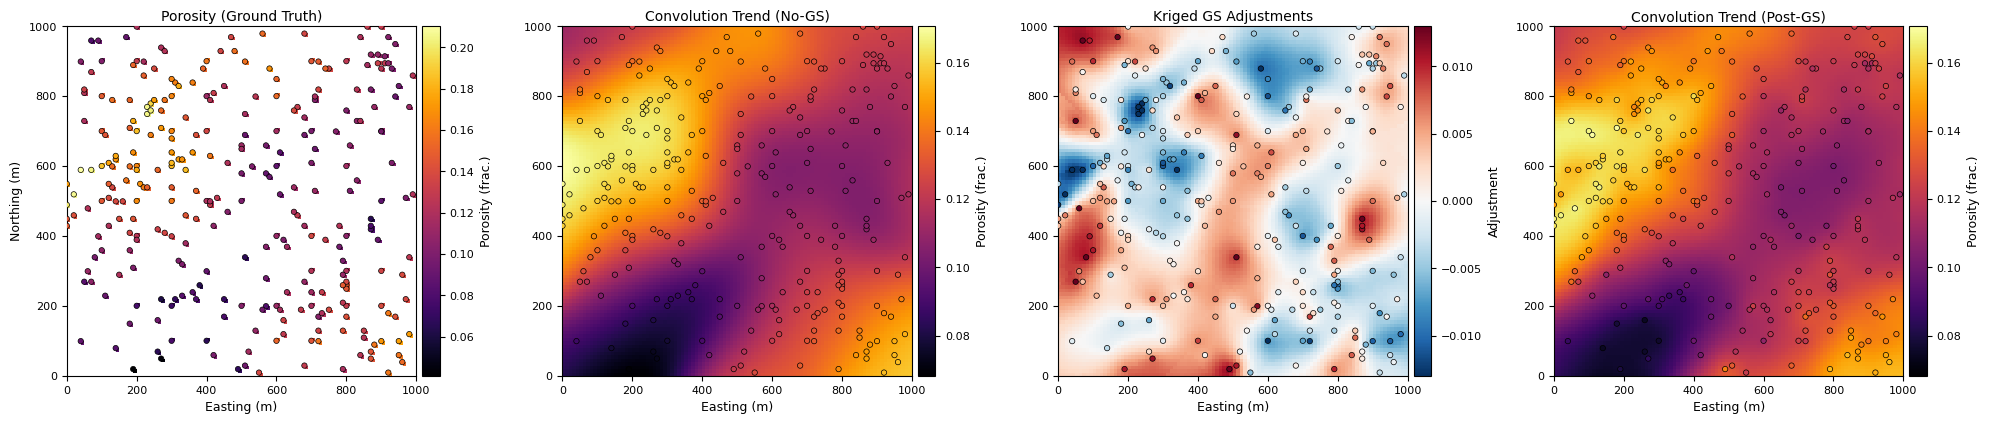

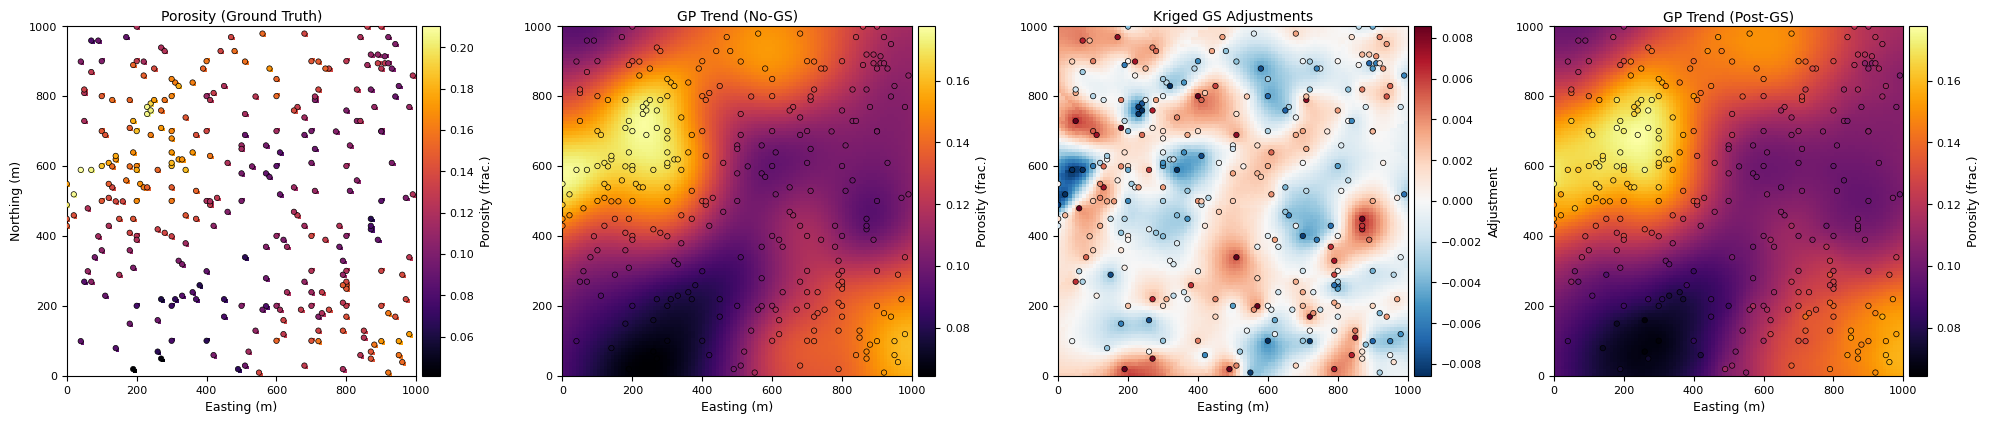

In [51]:
plot_reconstructed_fields(df_train, "Convolution", porosity_trend, Convolution_diff_kmap, Convolution_GS_Trend_grid)
plot_reconstructed_fields(df_train, "GP", GP_result["trend_grid"], GP_diff_kmap, GP_GS_Trend_grid)


Next, we compare the variance allocation before and after Gram–Schmidt orthogonalization for both the GP and convolution-based trend models. 

The results demonstrate that the procedure effectively removes the coupling (covariance) between the trend and residual components, regardless of the trend-fitting method used.

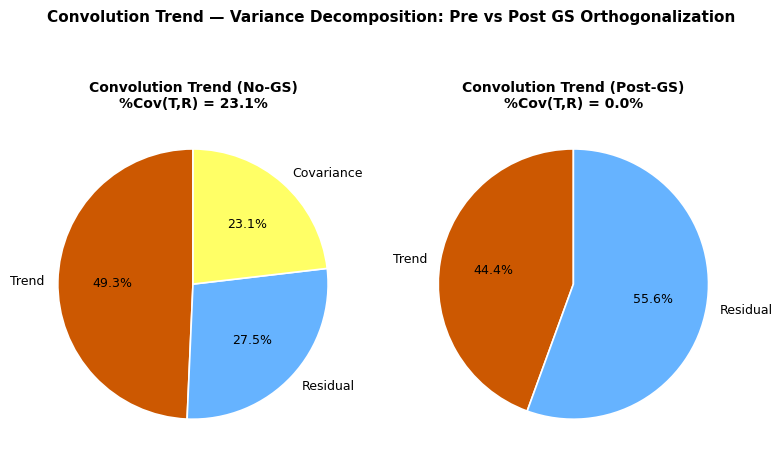

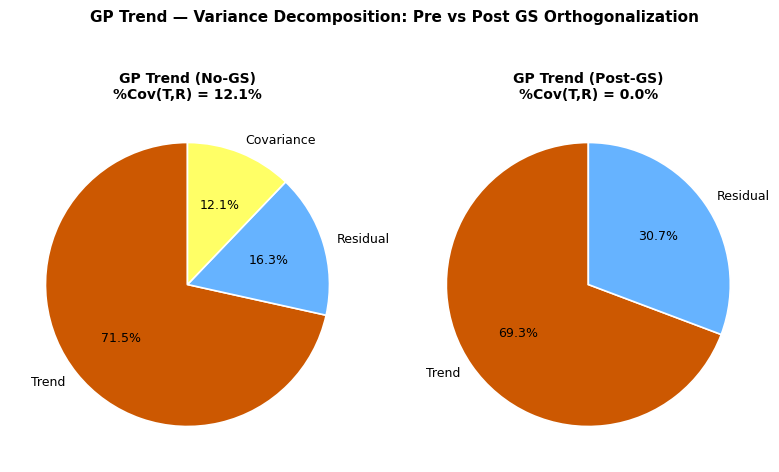

In [52]:
plot_variance_decomposition(df_train, "Convolution", colors=None)
plot_variance_decomposition(df_train, "GP", colors=None)

### 6. Variogram Modeling

With the correction applied, we now examine its impact on the residual variogram — the key diagnostic for whether the correction has decoupled shared variance. We compare the experimental variograms of the uncorrected and corrected residuals for both trend models side by side.

A higher sill in the corrected variogram confirms that coupled variance has been successfully reassigned from the trend back to the stochastic component. The gap between the two sills represents variance that would have been missing from the residual variogram and consequently from kriging or sequential Guassian simulation had the correction not been applied.

In [53]:
def plot_residual_variograms(df, xlag=25, xltol=22.5, nlag=40,
                              pair_threshold=100, figsize=(12, 5)):
    """
    Compare experimental residual variograms before and after GS orthogonalization.

    A successful correction raises the residual variogram sill toward the true 
    residual variance, confirming that the coupled variance has been reassigned 
    from the trend back to the stochastic component. Two panels are shown:
      - Left  : Convolution trend model
      - Right : GPR trend model

    Parameters
    ----------
    df              : DataFrame with columns X, Y, Convolution_Residual,
                      Convolution_GS_Residual, GP_Residual, GP_GS_Residual
    xlag            : lag spacing (m) — controls variogram resolution
    xltol           : lag tolerance (m) — pairs within this distance 
                      of a lag center are grouped together
    nlag            : number of lags — controls how far the variogram extends
    pair_threshold  : minimum data pairs per lag bin required to display 
                      a point — filters unreliable estimates at large distances
    figsize         : figure dimensions
    """
    gamv_kwargs = dict(
        tmin=-999, tmax=999,
        xlag=xlag, xltol=xltol, nlag=nlag,
        azm=0, atol=90, bandwh=9999.9, isill=0,
    )

    panels = [
        ("Convolution", "Convolution_Residual", "Convolution_GS_Residual"),
        ("GP",          "GP_Residual",          "GP_GS_Residual"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=False)

    for ax, (model_name, col_pre, col_post) in zip(axes, panels):

        # Compute experimental variograms for residuals before and after correction
        lags_pre,  var_pre,  pairs_pre  = geostats.gamv(df, "X", "Y", col_pre,  **gamv_kwargs)
        lags_post, var_post, pairs_post = geostats.gamv(df, "X", "Y", col_post, **gamv_kwargs)

        # Filter out lag bins with too few data pairs — unreliable at large distances
        mask_pre  = (pairs_pre  > pair_threshold) & np.isfinite(lags_pre)  & np.isfinite(var_pre)
        mask_post = (pairs_post > pair_threshold) & np.isfinite(lags_post) & np.isfinite(var_post)

        # Plot uncorrected residual variogram and corrected 
        # A higher sill in the corrected variogram confirms successful variance recovery
        ax.scatter(lags_pre[mask_pre],   var_pre[mask_pre],
                   color="orange", edgecolor="black", s=50, zorder=8,
                   label=f"{model_name} Residual (No-GS)")
        ax.scatter(lags_post[mask_post], var_post[mask_post],
                   color="steelblue", edgecolor="black", s=50, zorder=8,
                   label=f"{model_name} Residual (Post-GS)")

        ax.set_xlabel(r'Lag Distance $h$ (m)', fontsize=11)
        ax.set_ylabel(r'$\gamma(h)$',          fontsize=11)
        ax.set_title(f"{model_name} Model — Residual Variogram", fontsize=11, fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle("Residual Variogram: Pre vs Post GS Orthogonalization",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

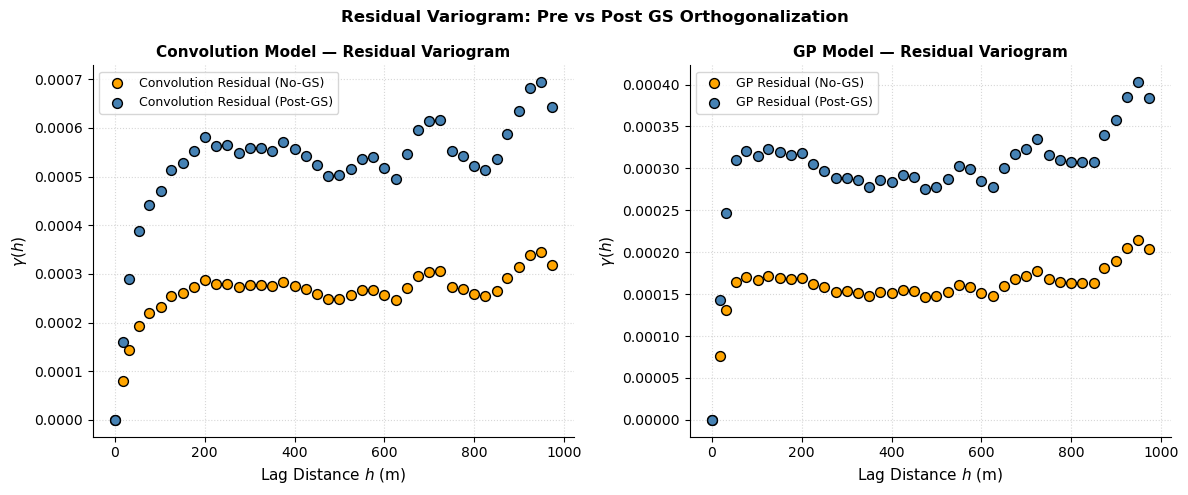

In [54]:
plot_residual_variograms(df_train, xlag=25, xltol=22.5, nlag=40, pair_threshold=100, figsize=(12, 5))

### 7. Effect on Downstream Kriging

With the corrected residuals in hand, we now examine how the Gram–Schmidt correction propagates downstream into kriging-based porosity reconstruction. To achieve this, we will krige both the uncorrected and corrected residuals, adds each back to its respective trend surface, and compares the resulting porosity maps and kriging variance fields side by side. 

- **Expectation:** The corrected workstream carries more variance, producing kriged maps with greater spatial detail and kriging variance fields that more honestly reflect local uncertainty across the reservoir.

In [55]:
from DIRECT2026_20_Ifenaike_variogram_tuner import *

def krige_residuals_and_reconstruct(
    df, model_name, trend_grid, gs_trend_grid,
    radius=None,
    figsize=(12, 10),
):
    """
    Krige pre- and post-GS residuals, reconstruct porosity, and compare results.

    Variogram model is fitted from the data using so that kriging and simulation demonstration
    share the same spatial correlation structure.  

    Row 0 : Porosity reconstructions  (Trend + Kriged Residual)
    Row 1 : Kriging variance maps     (shared colorscale for direct comparison)

    Parameters
    ----------
    df            : DataFrame with columns X, Y, {model_name}_Residual,
                    {model_name}_GS_Residual
    model_name    : "Convolution" or "GP"
    trend_grid    : uncorrected trend grid   (GSLIB convention, row 0 = top)
    gs_trend_grid : corrected trend grid     (GSLIB convention, row 0 = top)
    radius        : kriging search radius (m). 
    """
    if model_name.lower() not in ["convolution", "gp"]:
        raise ValueError("model_name must be 'Convolution' or 'GP'")

    col_pre  = f"{model_name}_Residual"
    col_post = f"{model_name}_GS_Residual"

    ktype = 1           # ordinary kriging 
    nxdis = 1; nydis = 1
    ndmin = 0; ndmax = 40
    tmin  = -99999.9; tmax = 99999.9

    # ── Fit variograms from data ──────────────────────────────────────────────
    vmodel_pre,  diag_pre  = auto_fit_variogram(df, col_pre,  fallback_range=250)
    vmodel_post, diag_post = auto_fit_variogram(df, col_post, fallback_range=250)

    print(f"  Pre-GS  variogram : {diag_pre['model']:12s} | "
          f"range={diag_pre['practical_range']:.0f}m | "
          f"η={diag_pre['structural_ratio_eta']:.2f}")
    print(f"  Post-GS variogram : {diag_post['model']:12s} | "
          f"range={diag_post['practical_range']:.0f}m | "
          f"η={diag_post['structural_ratio_eta']:.2f}")

    # Default search radius: 1.5× the larger fitted practical range
    if radius is None:
        radius = 1.5 * max(diag_pre["practical_range"], diag_post["practical_range"])
        print(f"  Search radius     : {radius:.0f} m  (auto)")

    # ── Rescale standardised variogram to actual variance for kb2d ────────────
    # auto_fit_variogram returns nug + cc1 = 1.0 (standardised).
    # kb2d needs sill in original units so the kriging variance is interpretable.
    def _scale_vario(vmodel, var_actual):
        return GSLIB.make_variogram(
            nug  = vmodel["nug"]  * var_actual,
            nst  = 1,
            it1  = vmodel["it1"],
            cc1  = vmodel["cc1"]  * var_actual,
            azi1 = vmodel["azi1"],
            hmaj1= vmodel["hmaj1"],
            hmin1= vmodel["hmin1"],
        )

    var_pre  = float(np.var(df[col_pre],  ddof=1))
    var_post = float(np.var(df[col_post], ddof=1))

    vario_pre  = _scale_vario(vmodel_pre,  var_pre)
    vario_post = _scale_vario(vmodel_post, var_post)

    # ── Kriging ───────────────────────────────────────────────────────────────
    kmap_pre, vmap_pre = geostats.kb2d(
        df, "X", "Y", col_pre,
        tmin, tmax, nx, xmn, xsiz, ny, ymn, ysiz,
        nxdis, nydis, ndmin, ndmax, radius, ktype, 0.0, vario_pre
    )
    kmap_post, vmap_post = geostats.kb2d(
        df, "X", "Y", col_post,
        tmin, tmax, nx, xmn, xsiz, ny, ymn, ysiz,
        nxdis, nydis, ndmin, ndmax, radius, ktype, 0.0, vario_post
    )

    # ── Reconstruct ───────────────────────────────────────────────────────────
    recon_pre  = trend_grid    + kmap_pre
    recon_post = gs_trend_grid + kmap_post

    vmin_var = min(vmap_pre [np.isfinite(vmap_pre )].min(),
                   vmap_post[np.isfinite(vmap_post)].min())
    vmax_var = max(vmap_pre [np.isfinite(vmap_pre )].max(),
                   vmap_post[np.isfinite(vmap_post)].max())

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    extent = [xmin, xmax, ymin, ymax]

    def _cbar(ax, im, label):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.06)
        cb  = fig.colorbar(im, cax=cax)
        cb.set_label(label, fontsize=9)
        cb.ax.tick_params(labelsize=8)

    recon_panels = [
        (axes[0, 0], recon_pre,  f"{model_name}: No-GS Reconstruction\n(Trend + Kriged Residual)"),
        (axes[0, 1], recon_post, f"{model_name}: Post-GS Reconstruction\n(GS Trend + Kriged GS Residual)"),
    ]
    for i, (ax, grid, title) in enumerate(recon_panels):
        im = ax.imshow(np.flipud(grid), origin="lower", extent=extent,
                       cmap=cmap, vmin=pormin, vmax=pormax, aspect="equal")
        ax.scatter(df["X"], df["Y"], c=df["Porosity"],
                   cmap=cmap, vmin=pormin, vmax=pormax,
                   s=15, edgecolors="k", linewidths=0.5, zorder=5)
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xlabel("Easting (m)", fontsize=9)
        if i == 0:
            ax.set_ylabel("Northing (m)", fontsize=9)
        ax.tick_params(labelsize=8)
        _cbar(ax, im, "Porosity (frac.)")

    var_panels = [
        (axes[1, 0], vmap_pre,  f"Kriging Variance — {model_name} No-GS Residual"),
        (axes[1, 1], vmap_post, f"Kriging Variance — {model_name} GS Residual"),
    ]
    for i, (ax, vmap, title) in enumerate(var_panels):
        im = ax.imshow(np.flipud(vmap), origin="lower", extent=extent,
                       cmap="YlOrRd", vmin=vmin_var, vmax=vmax_var, aspect="equal")
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xlabel("Easting (m)", fontsize=9)
        if i == 0:
            ax.set_ylabel("Northing (m)", fontsize=9)
        ax.tick_params(labelsize=8)
        _cbar(ax, im, "Kriging Variance")

    fig.suptitle(f"{model_name} Model — Porosity Reconstruction & Kriging Variance",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return {
        f"{model_name}_kmap_pre"      : kmap_pre,
        f"{model_name}_kmap_post"     : kmap_post,
        f"{model_name}_vmap_pre"      : vmap_pre,
        f"{model_name}_vmap_post"     : vmap_post,
        f"{model_name}_Recon_grid"    : recon_pre,
        f"{model_name}_GS_Recon_grid" : recon_post,
        f"{model_name}_vdiag_pre"     : diag_pre,
        f"{model_name}_vdiag_post"    : diag_post,
    }


  Pre-GS  variogram : exponential  | range=140m | η=0.99
  Post-GS variogram : exponential  | range=140m | η=0.99
  Search radius     : 210 m  (auto)
 make_variogram Warning: sill does not sum to 1.0, do not use in simulation 
 make_variogram Warning: sill does not sum to 1.0, do not use in simulation 
  Estimated   10000 blocks 
      average   -0.004133162070014902  variance  0.00011723019843341378
  Estimated   10000 blocks 
      average   -0.004758138583892478  variance  0.00023645719272155625


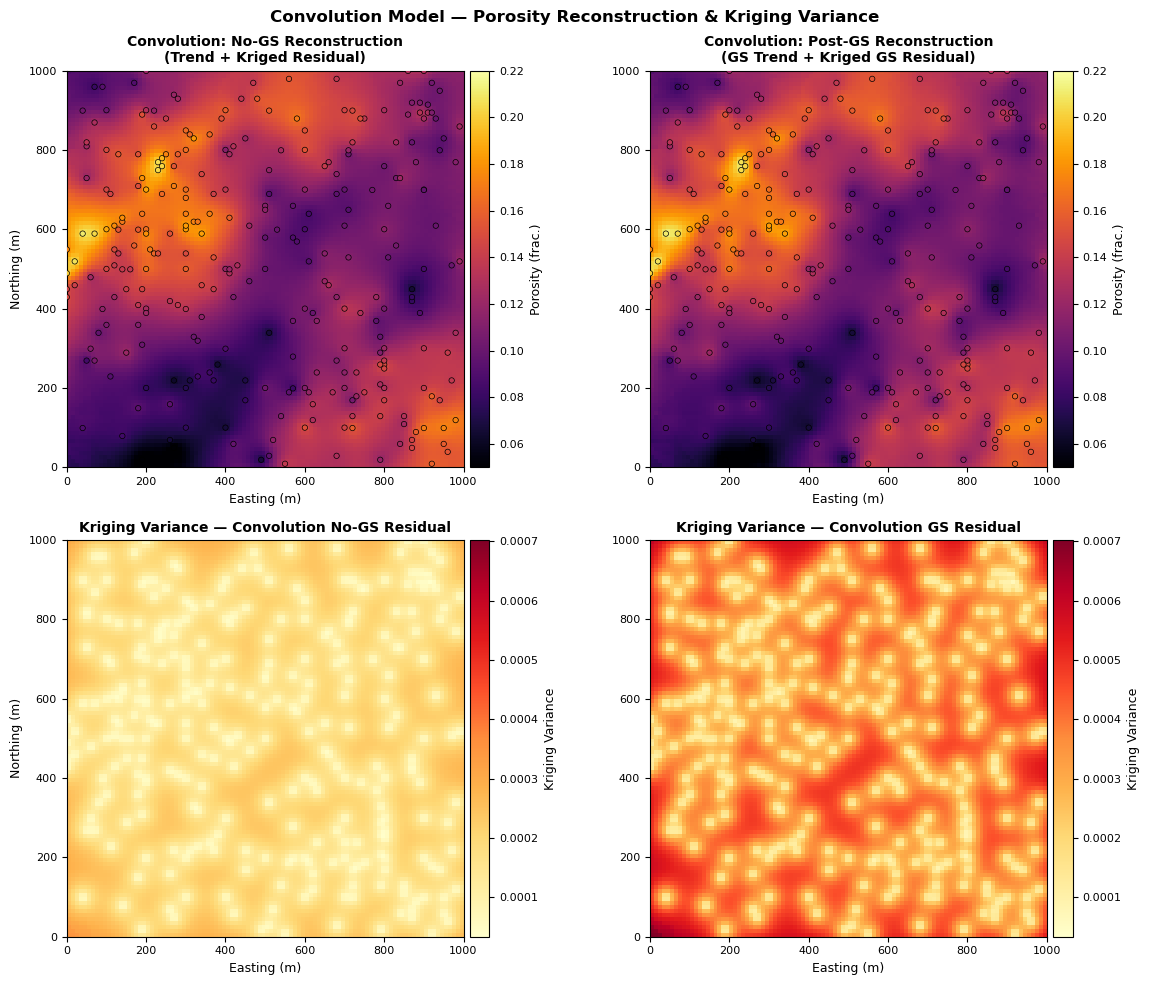

In [56]:
conv_krige_results = krige_residuals_and_reconstruct(
    df_train, "Convolution", porosity_trend, Convolution_GS_Trend_grid,
)


  Pre-GS  variogram : spherical    | range=50m | η=1.00
  Post-GS variogram : spherical    | range=50m | η=1.00
  Search radius     : 76 m  (auto)
 make_variogram Warning: sill does not sum to 1.0, do not use in simulation 
 make_variogram Warning: sill does not sum to 1.0, do not use in simulation 
  Estimated   10000 blocks 
      average   -0.0005761249118712672  variance  7.228377683598058e-05
  Estimated   10000 blocks 
      average   -0.0008193446470561336  variance  0.00013604244369821132


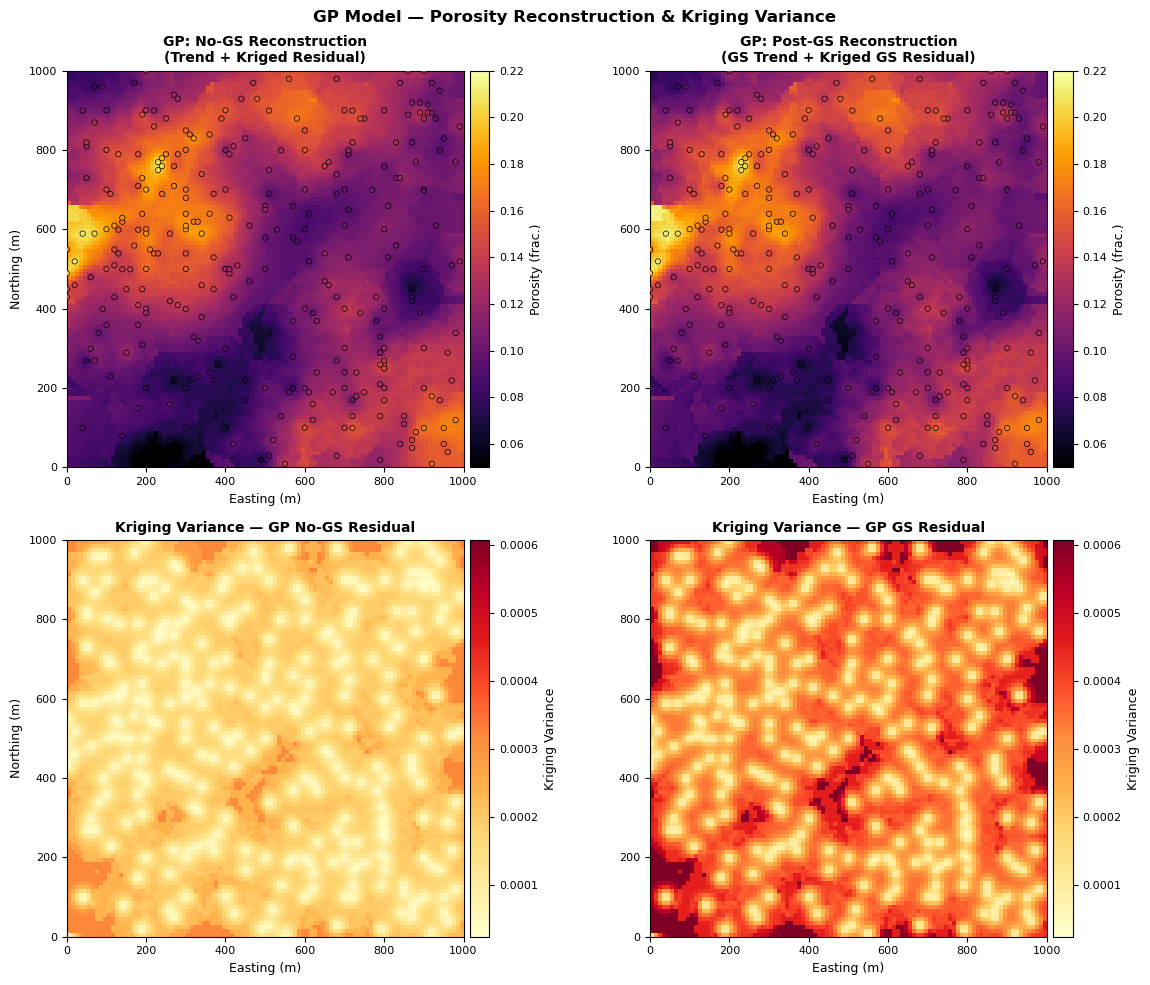

In [57]:
gp_krige_results = krige_residuals_and_reconstruct(
    df_train, "GP", GP_result["trend_grid"], GP_GS_Trend_grid,
)

Beyond the variogram, we examine two additional diagnostics to quantify how the Gram–Schmidt correction propagates into the kriged porosity field. 

- The variance ratio map shows spatially where the correction increased or decreased kriging uncertainty.
    
- The variance reproduction plot compares the spread of kriged grid values against the observed well distribution 

- **What to expect:** 
    - The variance ratio map should show values consistently above 1.0 across most of the domain, confirming the correction increased kriging variance everywhere. 
    - The post-GS histogram should be wider than the pre-GS histogram.

In [58]:
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# =============================================================================
# 1. Kriging Variance Ratio Map — Post-GS / Pre-GS
# =============================================================================

def plot_variance_ratio_map(krige_results_dict, figsize=(12, 5)):
    """
    Map the ratio of post-GS to pre-GS kriging variance across the reservoir.

    Ratio > 1 (red)  : correction increased local uncertainty — the corrected 
                       residual carries more variance, producing a more honest 
                       kriging variance estimate at that location
    Ratio < 1 (blue) : correction reduced local uncertainty — rare, indicates 
                       the corrected sill is locally lower than the uncorrected one
    Ratio = 1 (white): no change in kriging variance after correction

    A map dominated by red confirms that the GS correction propagates meaningfully 
    into downstream kriging uncertainty across the full simulation domain.
    """
    models = [("Convolution", krige_results_dict["Convolution"]),
              ("GP",          krige_results_dict["GP"])]

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    extent = [xmin, xmax, ymin, ymax]

    for ax, (model_name, kr) in zip(axes, models):
        vmap_pre  = kr[f"{model_name}_vmap_pre"]
        vmap_post = kr[f"{model_name}_vmap_post"]

        # Compute cell-wise variance ratio — mask near-zero pre-GS variance to avoid instability
        ratio  = np.where(vmap_pre > 1e-10, vmap_post / vmap_pre, np.nan)
        finite = ratio[np.isfinite(ratio)]

        lim  = max(np.exp(np.nanpercentile(np.abs(np.log(finite)), 98)), 1.05)
        norm = TwoSlopeNorm(vmin=1/lim, vcenter=1.0, vmax=lim)

        im = ax.imshow(np.flipud(ratio), origin="lower", extent=extent,
                       cmap="RdBu_r", norm=norm, aspect="equal")
        ax.set_title(f"{model_name} — Variance Ratio (Post-GS / Pre-GS)",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("Easting (m)", fontsize=9, fontweight="bold")
        ax.set_ylabel("Northing (m)", fontsize=9, fontweight="bold")
        ax.tick_params(labelsize=8)

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.06)
        cb  = fig.colorbar(im, cax=cax)
        cb.set_label("Variance Ratio", fontsize=9, fontweight="bold")
        cb.ax.tick_params(labelsize=8)
        cb.ax.axhline(1.0, color="black", linewidth=1.2)  # reference line at ratio = 1

    fig.suptitle("Kriging Variance Ratio: Post-GS / Pre-GS\n"
                 "Red > 1: correction increased uncertainty | Blue < 1: correction reduced uncertainty",
                 fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()


# =============================================================================
# 2. Variance Reproduction — Kriged Grid vs Observed Porosity Distribution
# =============================================================================

def plot_variance_reproduction(df, krige_results_dict, n_bins=35, figsize=(12, 4)):
    """
    Compare the spread of kriged porosity values against observed well data.

    Three distributions are compared per panel:
      - Black  : observed porosity at well locations (reference)
      - Orange : pre-GS kriged grid (deflated spread expected)
      - Blue   : post-GS kriged grid (improved spread expected)

    Standard deviation values in the legend quantify the spread of each distribution.
    """
    models = [("Convolution", krige_results_dict["Convolution"]),
              ("GP",          krige_results_dict["GP"])]

    z_obs = df["Porosity"].values

    # Shared bin edges across all three distributions for direct comparison
    bin_edges = np.linspace(
        min(pormin, z_obs.min()) - 0.005,
        max(pormax, z_obs.max()) + 0.005,
        n_bins + 1
    )

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=False)

    for ax, (model_name, kr) in zip(axes, models):
        recon_pre  = kr[f"{model_name}_Recon_grid"].ravel()
        recon_post = kr[f"{model_name}_GS_Recon_grid"].ravel()

        # Observed wells — reference distribution
        ax.hist(z_obs, bins=bin_edges, density=True, alpha=0.55,
                color="black", label=f"Observed wells  σ={z_obs.std():.4f}",
                edgecolor="black", linewidth=0.4)

        # Pre-GS reconstruction — expected to be narrower than observed (deflated sill)
        ax.hist(recon_pre, bins=bin_edges, density=True, alpha=0.5,
                color="#CC5801", label=f"Pre-GS grid  σ={recon_pre.std():.4f}",
                edgecolor="white", linewidth=0.3)

        # Post-GS reconstruction — should be wider, closer to observed spread
        ax.hist(recon_post, bins=bin_edges, density=True, alpha=0.5,
                color="#1f77b4", label=f"Post-GS grid  σ={recon_post.std():.4f}",
                edgecolor="white", linewidth=0.3)

        ax.set_title(f"{model_name} — Variance Reproduction",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("Porosity (frac.)", fontsize=9, fontweight="bold")
        ax.set_ylabel("Density",          fontsize=9, fontweight="bold")
        ax.legend(fontsize=8, framealpha=0.85)
        ax.grid(True, linestyle=":", alpha=0.4)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Variance Reproduction: Kriged Grid vs Observed Well Distribution",
                 fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()

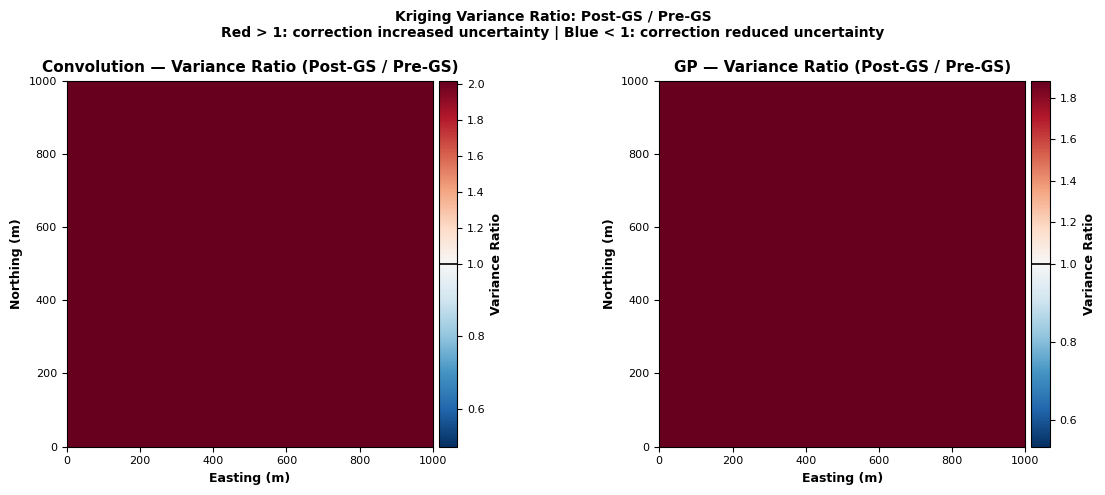

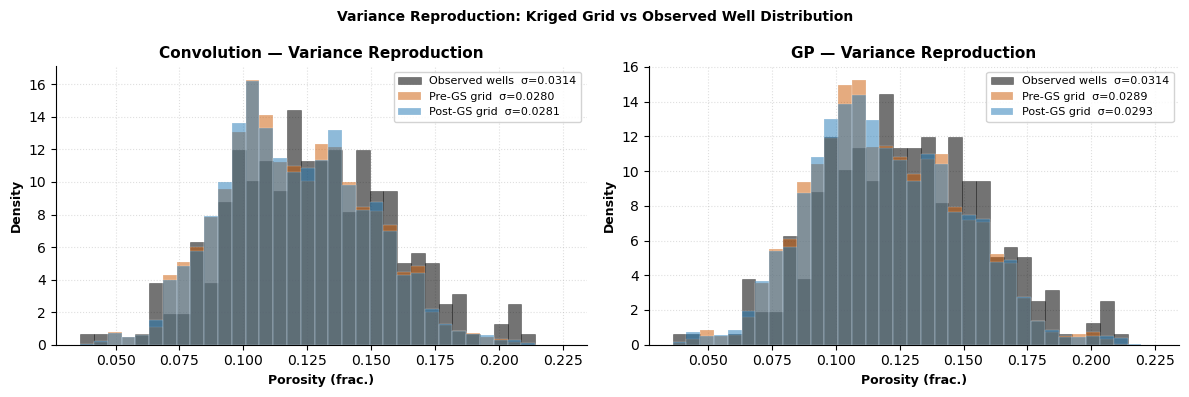

In [59]:
krige_results_dict = {"Convolution": conv_krige_results, "GP": gp_krige_results}

plot_variance_ratio_map(krige_results_dict)
plot_variance_reproduction(df_train, krige_results_dict)

### 8. Effect on realizations from Sequential Guassian Simulation

Next, we run Sequential Gaussian Simulation to generate an ensemble of equiprobable porosity realizations for both the uncorrected and corrected workflows. 

We run two parallel simulation tracks for each trend model: one using the original residuals and one using the GS-corrected residuals, each conditioned to their respective trend surface.

In [ ]:
from auto_variogram_tuner import *

def geostats_simulation(df, model_name, trend_grid, gs_trend_grid,
                         n_realizations=25, verbose=False):
    """
    Run Sequential Gaussian Simulation (SGS) on residuals for two parallel tracks:

      No-GS   : simulates uncorrected residuals → added back to original trend
      Post-GS : simulates GS-corrected residuals → added back to corrected trend

    Parameters
    ----------
    df               : DataFrame with X, Y, Porosity, and residual columns
    model_name       : "Convolution" or "GP"
    trend_grid       : uncorrected trend grid (GSLIB convention)
    gs_trend_grid    : GS-corrected trend grid (GSLIB convention)
    n_realizations   : number of SGS realizations to generate per track
    verbose          : print variogram fitting diagnostics if True

    """
    if model_name.lower() not in ["convolution", "gp"]:
        raise ValueError("model_name must be 'Convolution' or 'GP'")

    col_pre  = f"{model_name}_Residual"
    col_post = f"{model_name}_GS_Residual"

    # ── Declustering Weights ─────────────────────────────────────────────────
    # To correct for sampling bias by downweighting densely sampled clusters so the global distribution used in SGS is unbiased.
    try:
        wts, _, _ = geostats.declus(df, "X", "Y", "Porosity",
                                     iminmax=1, noff=10,
                                     ncell=100, cmin=1, cmax=5000)
    except IndexError:
        # Fallback to equal weights if declustering fails (e.g. too few wells)
        wts = np.ones(len(df))

    df_copy = df.copy()
    df_copy["Wts_cell"] = wts
    df_copy[int(df_copy.columns.get_loc("Wts_cell"))] = wts   # integer-keyed for sgsim compatibility

    # ── Automated Variogram Fitting ──────────────────────────────────────────
    # Fit separate variogram models for uncorrected and corrected residuals.
    vmodel_pre,  vdiag_pre  = auto_fit_variogram(df_copy, col_pre,  fallback_range=250)
    vmodel_post, vdiag_post = auto_fit_variogram(df_copy, col_post, fallback_range=250)

    # ── SGS Inner Function ───────────────────────────────────────────────────
    def _sgsim(col, vmodel, seed_off):
        dat = df_copy[col]
        sig = dat.std()

        # Cap search radius to prevent memory blowup for long-range variograms —
        # limits the neighbourhood search to a sensible multiple of grid spacing
        MAX_RADIUS = 5 * dx * (20 ** 0.5)
        vm = dict(vmodel)
        if vm["hmaj1"] > MAX_RADIUS:
            vm["hmaj1"] = MAX_RADIUS
            vm["hmin1"] = min(vm["hmin1"], MAX_RADIUS)

        return geostats.sgsim(
            df, "X", "Y", col,
            wcol=-1, scol=-1,                      # no external weight or secondary column
            tmin=-9999.9, tmax=9999.9,             # no data trimming
            itrans=1, ismooth=0,                   # normal score transform: on | smoothing: off
            dftrans=0, tcol=0, twtcol=0,
            zmin=dat.min() - 0.5 * sig,            # lower tail extrapolation bound
            zmax=dat.max() + 0.5 * sig,            # upper tail extrapolation bound
            ltail=2, ltpar=1.5,                    # power model tail extrapolation
            utail=2, utpar=1.5,
            nsim=n_realizations,
            nx=nx, xmn=dx / 2, xsiz=dx,           # simulation grid definition
            ny=ny, ymn=dx / 2, ysiz=dx,
            seed=2045 + seed_off,                  # reproducible but distinct seeds per track
            ndmin=0, ndmax=10, nodmax=10,          # conditioning data search parameters
            mults=0, nmult=2, noct=-1,
            ktype=0,                               # simple kriging for residuals (zero-mean)
            colocorr=0.0, sec_map=0,
            vario=vm,
        )

    # Run SGS for both tracks
    sgs_pre  = _sgsim(col_pre,  vmodel_pre,  seed_off=0)
    sgs_post = _sgsim(col_post, vmodel_post, seed_off=1)

    # ── Reconstruct Porosity Realizations ────────────────────────────────────
    # Add each set of simulated residuals back to its respective trend surface.
    hybrid_pre  = trend_grid[np.newaxis]    + sgs_pre    # uncorrected: original trend + simulated residuals
    hybrid_post = gs_trend_grid[np.newaxis] + sgs_post   # corrected: GS trend + corrected simulated residuals

    return {
        f"{model_name}_hybrid_pre"  : hybrid_pre,    # (n_realizations, ny, nx) uncorrected ensemble
        f"{model_name}_hybrid_post" : hybrid_post,   # (n_realizations, ny, nx) corrected ensemble
        f"{model_name}_sgs_pre"     : sgs_pre,       # raw simulated residuals (no GS)
        f"{model_name}_sgs_post"    : sgs_post,      # raw simulated residuals (post GS)
        f"{model_name}_vdiag_pre"   : vdiag_pre,     # variogram diagnostics (no GS)
        f"{model_name}_vdiag_post"  : vdiag_post,    # variogram diagnostics (post GS)
    }, df_copy

In [ ]:
# Generate 25 realizations from SGS on Convolution residuals before and after GS correction
conv_sgs_results, conv_df = geostats_simulation(df_train, "Convolution", porosity_trend, Convolution_GS_Trend_grid)

There are 295 data with:
   mean of      0.12735328822339886 
   min and max  0.0411215184025049 and 0.2102576261742328
   standard dev 0.031370348136507104 

 Data for SGSIM: Number of acceptable data     = 295
                 Number trimmed                = 0
                 Weighted Average              = -0.0026
                 Weighted Variance             = 0.0003
                 Weighted Transformed Average  = 0.0001
                 Weighted Transformed Variance = 0.996
Setting up rotation matrices for variogram and search
Working on realization number 0
   currently on node 0
   currently on node 1000
   currently on node 2000
   currently on node 3000
   currently on node 4000
   currently on node 5000
   currently on node 6000
   currently on node 7000
   currently on node 8000
   currently on node 9000
Reassigning data to nodes

 Realization 0: number   = 10000
                                   mean     = -0.1521 (close to 0.0?)
                                   varia

In [ ]:
# Generate 25 realizations from SGS on GP residuals before and after GS correction
gp_sgs_results,   gp_df = geostats_simulation(df_train, "GP", GP_result["trend_grid"], GP_GS_Trend_grid)

There are 295 data with:
   mean of      0.12735328822339886 
   min and max  0.0411215184025049 and 0.2102576261742328
   standard dev 0.031370348136507104 

 Data for SGSIM: Number of acceptable data     = 295
                 Number trimmed                = 0
                 Weighted Average              = 0.0001
                 Weighted Variance             = 0.0002
                 Weighted Transformed Average  = 0.0001
                 Weighted Transformed Variance = 0.9957
Setting up rotation matrices for variogram and search
Working on realization number 0
   currently on node 0
   currently on node 1000
   currently on node 2000
   currently on node 3000
   currently on node 4000
   currently on node 5000
   currently on node 6000
   currently on node 7000
   currently on node 8000
   currently on node 9000
Reassigning data to nodes

 Realization 0: number   = 10000
                                   mean     = -0.0762 (close to 0.0?)
                                   varia

Next, we evaluate uncertainty calibration at held-out well locations that were never used in trend modeling or simulation, providing an honest, out-of-sample test of both workflows.


Three metrics are reported for each model and track:

- The coverage accuracy plot shows whether nominal probability intervals actually contain the true porosity values. 

- The Goodness score which summarizes the coverage plot into a single number between 0 and 1, penalizing overconfident intervals (undercoverage) twice as heavily as conservative ones. 

- The Variance Inflation Factor which measures whether the ensemble spread matches the true spatial variability at holdout locations.

In [66]:
# =============================================================================
# Holdout Validation — Coverage & VIF at held-out well locations
# =============================================================================

def _extract_at_wells(hybrid, df_wells):
    """
    Extract realization values at well (X, Y) locations from a GSLIB-convention
    ensemble stack. Returns shape (n_real, n_wells).
    """
    ix_w = np.clip(((df_wells["X"].values - xmin) / xsiz).astype(int), 0, nx - 1)
    iy_w = np.clip((ny - 1 - ((df_wells["Y"].values - ymin) / ysiz)).astype(int), 0, ny - 1)
    return hybrid[:, iy_w, ix_w]          # (n_real, n_wells)


def compute_coverage_at_holdout(df_holdout, hybrid, nominal_levels=None):
    """
    Actual coverage at each nominal level, evaluated at holdout well locations.

    Parameters
    ----------
    df_holdout      : DataFrame with columns X, Y, Porosity
    hybrid          : ndarray (n_real, ny, nx), GSLIB convention
    nominal_levels  : 1-D array of probabilities in (0, 1)

    Returns
    -------
    nominal_levels, actual_coverage : both 1-D ndarrays
    """
    if nominal_levels is None:
        nominal_levels = np.arange(0.02, 1.0, 0.02)
    nominal_levels = np.asarray(nominal_levels)

    z_obs  = df_holdout["Porosity"].values           # (n_wells,)
    dist   = _extract_at_wells(hybrid, df_holdout)   # (n_real, n_wells)

    actual_coverage = np.zeros(len(nominal_levels))
    for i, p in enumerate(nominal_levels):
        lo = np.percentile(dist, (1.0 - p) / 2.0 * 100.0, axis=0)
        hi = np.percentile(dist, (1.0 + p) / 2.0 * 100.0, axis=0)
        actual_coverage[i] = np.mean((z_obs >= lo) & (z_obs <= hi))

    return nominal_levels, actual_coverage

def deutsch_goodness(nominal_levels, actual_coverage):
    """
    Compute the Deutsch (1997) Goodness statistic G from "Direct Assessment of Local Accuracy and Precision".

    Penalty weights:
        - Overcoverage (above 45° line): w(p) = 1
        - Undercoverage (below 45° line): w(p) = -2

    The denominator normalizes by the worst-case penalty so G stays in [0, 1].

    Undercoverage is penalized twice as heavily because overconfident
    predictions (intervals too narrow) are worse than conservative ones.

    Parameters
    ----------
    nominal_levels : Nominal coverage levels (between 0 and 1).
    actual_coverage : Corresponding actual coverage fractions.

    """
    nominal_levels = np.asarray(nominal_levels, dtype=float)
    actual_coverage = np.asarray(actual_coverage, dtype=float)

    overcoverage = actual_coverage >= nominal_levels  

    weight = np.where(overcoverage, 1.0, -2.0)         
    deviation = actual_coverage - nominal_levels         
    integrand = weight * deviation                       

    penalty_integral = np.trapz(integrand, nominal_levels)
    G = 1.0 - penalty_integral

    return G

def compute_vif_at_holdout(df_holdout, hybrid):
    """
    VIF = mean per-realization variance across holdout well values
          / var(observed porosity at holdout wells)

    VIF > 1 → ensemble realizations are more spread across space than observed.
    VIF < 1 → ensemble is under-dispersed spatially.
    """
    dist = _extract_at_wells(hybrid, df_holdout)  # (n_real, n_wells)

    # Variance of each realization across holdout well locations
    var_per_real      = np.var(dist, axis=1, ddof=1)   # (n_real,)  ← axis=1, not axis=0
    mean_var_ensemble = float(np.mean(var_per_real))

    var_obs = float(np.var(df_holdout["Porosity"].values, ddof=1))

    return mean_var_ensemble / var_obs



def plot_holdout_validation(df_holdout, conv_sgs_results, gp_sgs_results,
                            nominal_levels=None, figsize=(12, 5)):
    """
    Side-by-side coverage accuracy plots for Convolution and GP models.
    Prints Goodness score and VIF for Pre-GS and Post-GS in each model.
    """
    if nominal_levels is None:
        nominal_levels = np.arange(0.02, 1.0, 0.02)

    model_configs = [
        ("Convolution", conv_sgs_results),
        ("GP",          gp_sgs_results),
    ]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    print("=" * 58)
    print(f"{'Holdout Validation':^58}")
    print(f"{'n = ' + str(len(df_holdout)) + ' held-out wells':^58}")
    print("=" * 58)

    for ax, (model_name, sgs_results) in zip(axes, model_configs):
        hybrid_pre  = sgs_results[f"{model_name}_hybrid_pre"]
        hybrid_post = sgs_results[f"{model_name}_hybrid_post"]

        # ── Coverage curves ───────────────────────────────────────────────
        nom_pre,  act_pre  = compute_coverage_at_holdout(df_holdout, hybrid_pre,  nominal_levels)
        nom_post, act_post = compute_coverage_at_holdout(df_holdout, hybrid_post, nominal_levels)

        # ── Goodness scores ───────────────────────────────────────────────
        G_pre  = deutsch_goodness(nom_pre,  act_pre)
        G_post = deutsch_goodness(nom_post, act_post)

        # ── VIF ───────────────────────────────────────────────────────────
        vif_pre  = compute_vif_at_holdout(df_holdout, hybrid_pre)
        vif_post = compute_vif_at_holdout(df_holdout, hybrid_post)

        print(f"\n  {model_name}")
        print(f"    {'':20s}  {'Pre-GS':>10s}  {'Post-GS':>10s}")
        print(f"    {'Goodness (G)':20s}  {G_pre:>10.3f}  {G_post:>10.3f}")
        print(f"    {'VIF (holdout)':20s}  {vif_pre:>10.3f}  {vif_post:>10.3f}")

        # ── Plot ──────────────────────────────────────────────────────────
        # Anchor at (0, 0)
        nom_pre_p  = np.r_[0, nom_pre];  act_pre_p  = np.r_[0, act_pre]
        nom_post_p = np.r_[0, nom_post]; act_post_p = np.r_[0, act_post]

        ax.plot([0, 1], [0, 1], "k--", linewidth=1.2,
                label="Perfect calibration", zorder=2)
        ax.plot(nom_pre_p,  act_pre_p,  "o-", color="#E74C3C", linewidth=2,
                markersize=4, label=f"Pre-GS   G={G_pre:.3f}  VIF={vif_pre:.3f}", zorder=3)
        ax.plot(nom_post_p, act_post_p, "s-", color="#2E86C1", linewidth=2,
                markersize=4, label=f"Post-GS  G={G_post:.3f}  VIF={vif_post:.3f}", zorder=3)

        ax.fill_between(nom_pre_p,  nom_pre_p,  act_pre_p,  color="#E74C3C", alpha=0.07)
        ax.fill_between(nom_post_p, nom_post_p, act_post_p, color="#2E86C1", alpha=0.07)

        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
        ax.set_xlabel("Nominal Coverage", fontsize=10, fontweight="bold")
        ax.set_ylabel("Actual Coverage at Holdout Wells", fontsize=10, fontweight="bold")
        ax.set_title(f"{model_name} — Uncertainty Calibration\n(holdout n={len(df_holdout)})",
                     fontsize=11, fontweight="bold")
        ax.legend(fontsize=8.5, loc="upper left", framealpha=0.9, edgecolor="grey")
        ax.grid(True, alpha=0.3, linewidth=0.6)
        ax.spines[["top", "right"]].set_visible(False)

    print("=" * 58)
    fig.suptitle("Holdout Validation — Coverage Accuracy: Pre-GS vs Post-GS",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()



                    Holdout Validation                    
                  n = 73 held-out wells                   

  Convolution
                              Pre-GS     Post-GS
    Goodness (G)               0.935       0.972
    VIF (holdout)              1.111       1.339

  GP
                              Pre-GS     Post-GS
    Goodness (G)               0.927       0.968
    VIF (holdout)              1.058       1.208


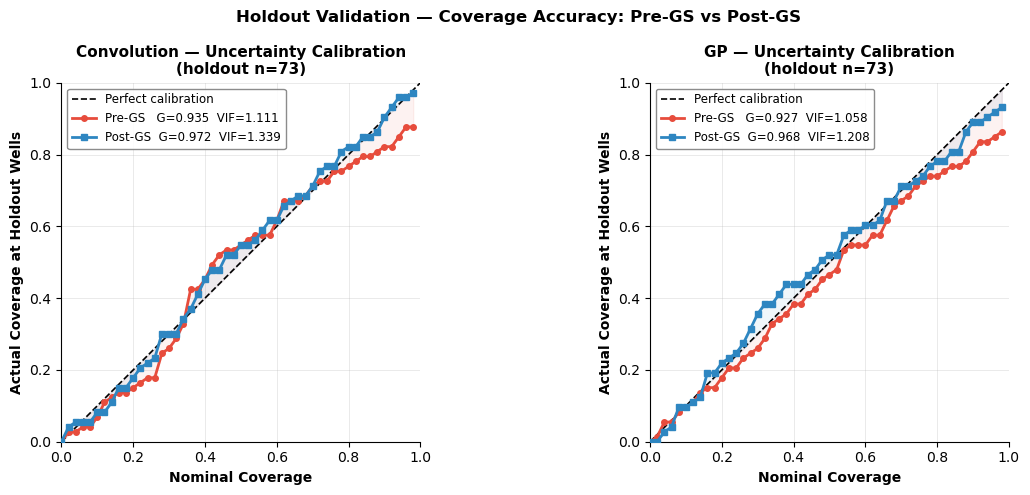

In [67]:
plot_holdout_validation(df_holdout, conv_sgs_results, gp_sgs_results)

Finally, let's take a look at a sample realization and the e-type model from each workstream.

In [68]:
def plot_sample_realization(conv_sgs_results, gp_sgs_results, df_train,
                             real_idx=0, figsize=(18, 9)):
    """
    2×2: one realization (real_idx) for each model × workstream.
    """
    panels = [
        ("Convolution", "Pre-GS",  conv_sgs_results["Convolution_hybrid_pre"]),
        ("Convolution", "Post-GS", conv_sgs_results["Convolution_hybrid_post"]),
        ("GP",          "Pre-GS",  gp_sgs_results["GP_hybrid_pre"]),
        ("GP",          "Post-GS", gp_sgs_results["GP_hybrid_post"]),
    ]

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    extent = [xmin, xmax, ymin, ymax]

    for ax, (model_name, label, hybrid) in zip(axes.ravel(), panels):
        grid = np.flipud(hybrid[real_idx])          # GSLIB → display convention
        im = ax.imshow(grid, origin="lower", extent=extent,
                       cmap=cmap, vmin=pormin, vmax=pormax, aspect="equal")
        ax.scatter(df_train["X"], df_train["Y"], c=df_train["Porosity"],
                   cmap=cmap, vmin=pormin, vmax=pormax,
                   s=10, edgecolors="k", linewidths=0.4, zorder=5)
        ax.set_title(f"{model_name} — {label}  (Realization {real_idx + 1})",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("Easting (m)", fontsize=9, fontweight="bold")
        ax.set_ylabel("Northing (m)", fontsize=9, fontweight="bold")
        ax.tick_params(labelsize=8)

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.06)
        cb = fig.colorbar(im, cax=cax)
        cb.set_label("Porosity (frac.)", fontsize=8)
        cb.ax.tick_params(labelsize=7)

    fig.suptitle(f"Sample Realization {real_idx + 1} — Pre-GS vs Post-GS",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_etype(conv_sgs_results, gp_sgs_results, df_train, figsize=(18, 9)):
    """
    2×2: E-type (ensemble mean) for each model × workstream.
    """
    panels = [
        ("Convolution", "Pre-GS",  conv_sgs_results["Convolution_hybrid_pre"]),
        ("Convolution", "Post-GS", conv_sgs_results["Convolution_hybrid_post"]),
        ("GP",          "Pre-GS",  gp_sgs_results["GP_hybrid_pre"]),
        ("GP",          "Post-GS", gp_sgs_results["GP_hybrid_post"]),
    ]

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    extent = [xmin, xmax, ymin, ymax]

    for ax, (model_name, label, hybrid) in zip(axes.ravel(), panels):
        etype = np.flipud(np.mean(hybrid, axis=0))   # mean across realizations
        im = ax.imshow(etype, origin="lower", extent=extent,
                       cmap=cmap, vmin=pormin, vmax=pormax, aspect="equal")
        ax.scatter(df_train["X"], df_train["Y"], c=df_train["Porosity"],
                   cmap=cmap, vmin=pormin, vmax=pormax,
                   s=10, edgecolors="k", linewidths=0.4, zorder=5)
        ax.set_title(f"{model_name} — {label}  (E-type, n={hybrid.shape[0]} realizations)",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("Easting (m)", fontsize=9, fontweight="bold")
        ax.set_ylabel("Northing (m)", fontsize=9, fontweight="bold")
        ax.tick_params(labelsize=8)

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.06)
        cb = fig.colorbar(im, cax=cax)
        cb.set_label("Porosity (frac.)", fontsize=8)
        cb.ax.tick_params(labelsize=7)

    fig.suptitle("E-type (Ensemble Mean) — Pre-GS vs Post-GS",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()



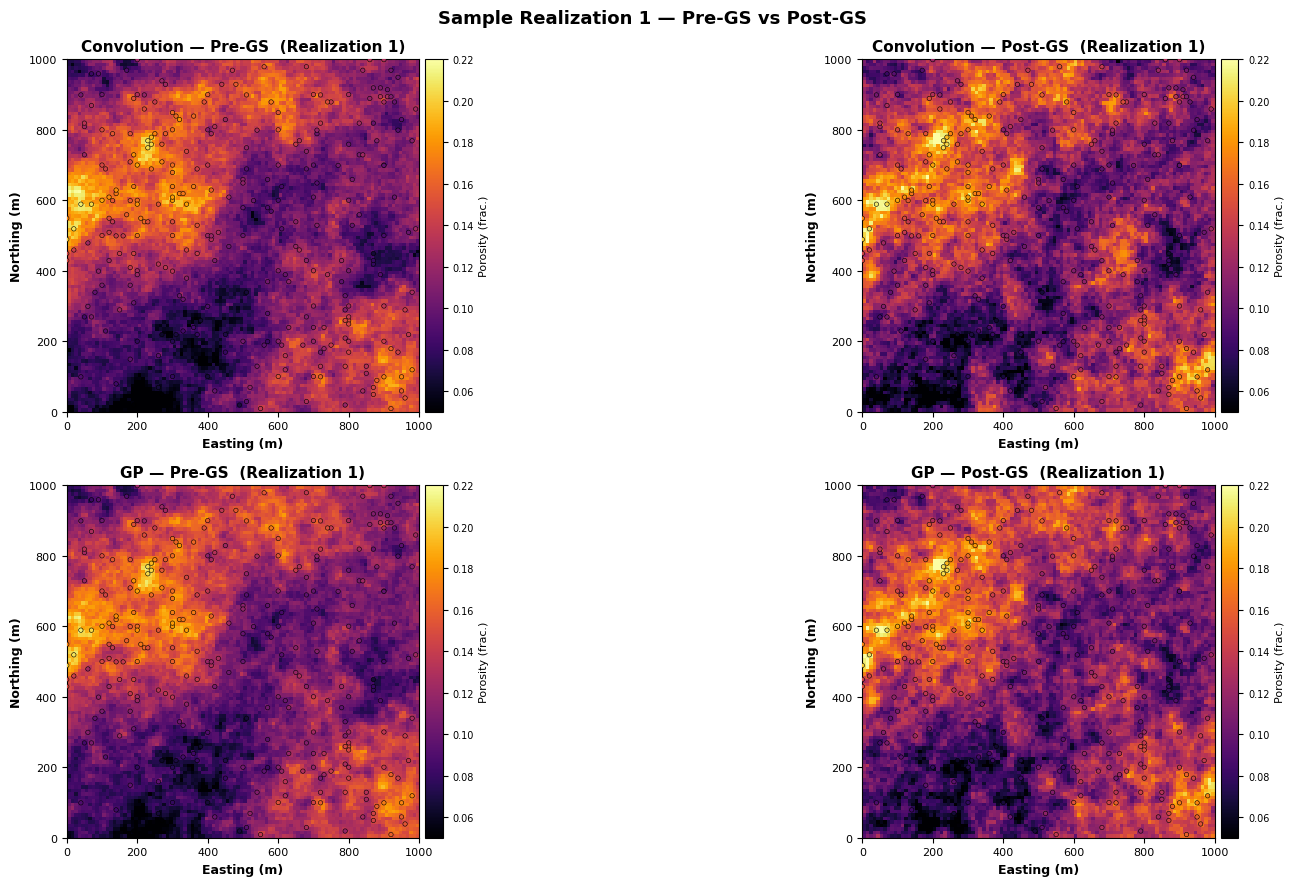

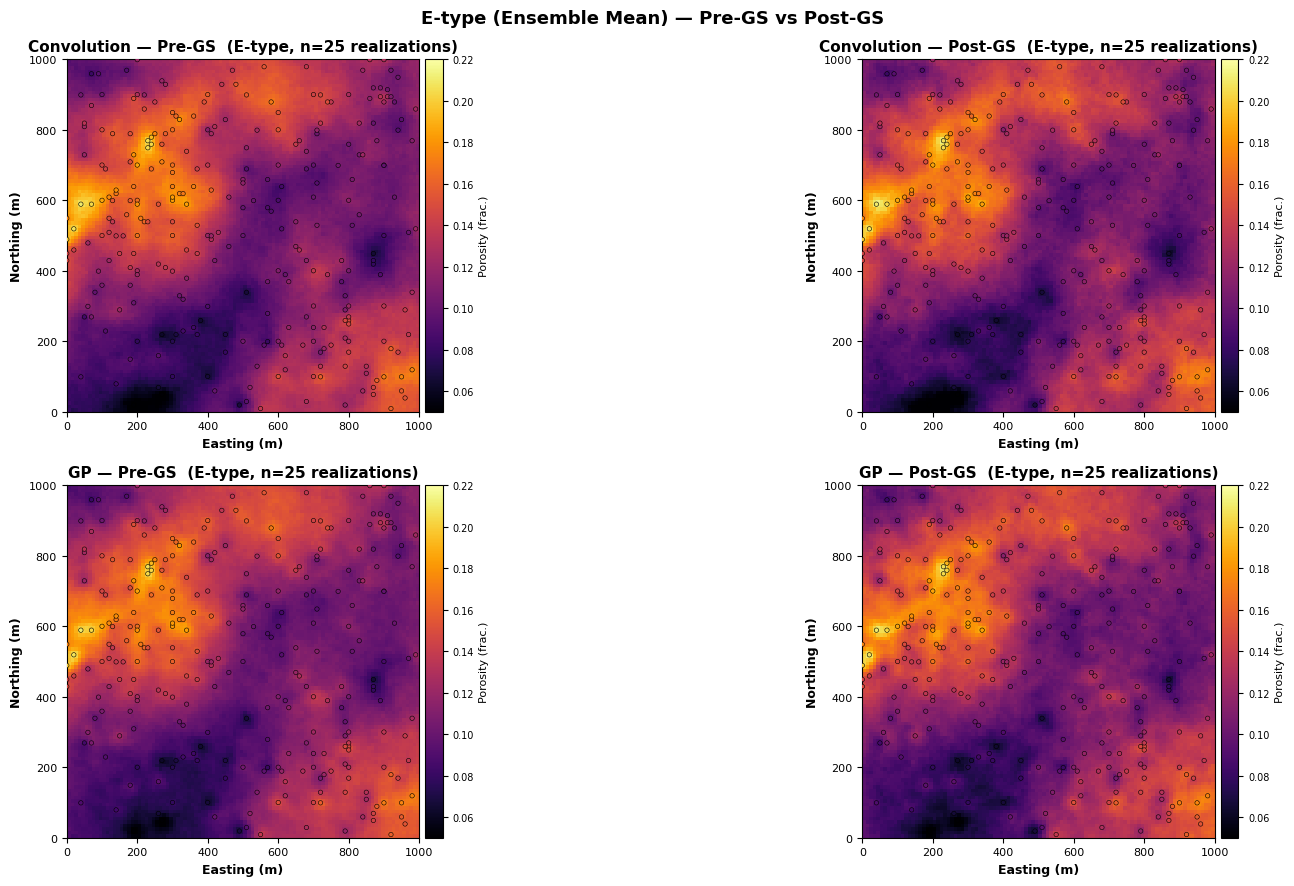

In [69]:
plot_sample_realization(conv_sgs_results, gp_sgs_results, df_train, real_idx=0)
plot_etype(conv_sgs_results, gp_sgs_results, df_train)


**Thank you for following along with the demonstration!**